# Environment Setup

In [9]:
from tqdm.auto import tqdm

In [ ]:
# ============================================================
# Environment setup for reproducible ML experiments
# Run this cell ONCE at the start of the notebook
# ============================================================

import sys
import subprocess

def pip_install(packages):
    for pkg in packages:
        try:
            __import__(pkg.split("==")[0])
            print(f"✓ {pkg} already installed")
        except ImportError:
            print(f"Installing {pkg} ...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Core scientific stack
core_packages = [
    "numpy",
    "scipy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "joblib"
]

# Gradient boosting & tabular ML
ml_packages = [
    "xgboost",
    "lightgbm",
    "catboost"
]

# Materials science / featurization
materials_packages = [
    "pymatgen",
    "matminer"
]

# Run installation
pip_install(core_packages + ml_packages + materials_packages)

print("\n✅ Environment setup complete. Restart kernel if any package was newly installed.")


# Dataset Preparation

In [ ]:
# ============================================================
# QE SCF + BANDS → TOPOLOGICAL DATASET (LOW-RAM STREAMING)
# ============================================================

import os
import re
import csv
import numpy as np

# ------------------------
# CONFIGURATION (RELATIVE PATHS)
# ------------------------
BASE_DIR = "Files"
SCF_DIR = "Files/scf.out"
BANDS_DIR = "Files/bands.out"
OUT_DIR = "Files/output"
OUT_CSV = "Files/output/qe_topo_dataset.csv"

import os
os.makedirs(OUT_DIR, exist_ok=True)


# ------------------------
# ATOMIC NUMBERS (SOC PROXY)
# ------------------------
ATOMIC_Z = {
    "H":1,"C":6,"N":7,"O":8,"F":9,"S":16,"Cl":17,"Se":34,
    "Br":35,"I":53,"Te":52,"Ag":47,"Hg":80,"Pb":82,"Bi":83,
    "Ge":32,"Sn":50,"Sb":51,"Mo":42,"W":74,"Hf":72,"Cs":55,
    "Cr":24,"Mn":25,"Fe":26,"Co":27,"Ni":28
}

# ------------------------
# HELPERS
# ------------------------
def extract_formula(material_id):
    return material_id.split("_")[0]

def chemistry_features(formula):
    elems = re.findall(r"[A-Z][a-z]?", formula)
    Zs = [ATOMIC_Z.get(e, 0) for e in elems]
    return {
        "num_elements": len(set(elems)),
        "max_atomic_Z": max(Zs) if Zs else 0,
        "heavy_element_flag": int(any(z >= 50 for z in Zs))
    }

# ------------------------
# SCF PARSER (STREAM SAFE)
# ------------------------
def parse_scf(filepath):
    data = {
        "total_energy_ry": None,
        "fermi_energy_ev": None,
        "total_magnetization": None,
        "absolute_magnetization": None,
        "converged": 0
    }

    with open(filepath, "r", errors="ignore") as f:
        for line in f:
            if "!" in line and "total energy" in line:
                data["total_energy_ry"] = float(line.split()[-2])
            elif "the Fermi energy is" in line:
                data["fermi_energy_ev"] = float(line.split()[-2])
            elif "total magnetization" in line.lower():
                data["total_magnetization"] = float(line.split()[-1])
            elif "absolute magnetization" in line.lower():
                data["absolute_magnetization"] = float(line.split()[-1])
            elif "convergence has been achieved" in line.lower():
                data["converged"] = 1
    return data

# ------------------------
# BANDS PARSER (STREAM SAFE)
# ------------------------
def parse_bands(filepath):
    bands_raw = []
    current = []

    with open(filepath, "r", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if line.startswith("k ="):
                if current:
                    bands_raw.append(current)
                    current = []
                continue

            if not line or set(line) == {"-"}:
                continue

            for token in line.split():
                try:
                    current.append(float(token))
                except ValueError:
                    pass

        if current:
            bands_raw.append(current)

    # ---- Enforce uniform band count ----
    lengths = [len(b) for b in bands_raw]
    if not lengths:
        return None

    target_len = max(set(lengths), key=lengths.count)

    # Keep only well-formed k-points
    bands = [b for b in bands_raw if len(b) == target_len]

    if len(bands) < 2:
        return None

    return np.array(bands, dtype=float)


# ------------------------
# TOPOLOGICAL PROXIES
# ------------------------
def topo_features(bands, Ef):
    flat = bands.flatten()
    Nk, Nb = bands.shape

    # crossings
    crossings = 0
    for b in bands.T:
        crossings += np.sum((b[:-1] - Ef) * (b[1:] - Ef) < 0)

    dos_proxy = np.sum(np.abs(flat - Ef) < 0.05)

    gaps = []
    for k in bands:
        below = k[k < Ef]
        above = k[k > Ef]
        if len(below) and len(above):
            gaps.append(min(above) - max(below))

    min_gap = min(gaps) if gaps else 0.0

    vel = np.diff(bands, axis=0)
    vel_var = np.var(vel, axis=0)

    return {
        "Nk": Nk,
        "Nb": Nb,
        "bandwidth_ev": flat.max() - flat.min(),
        "min_gap_ev": min_gap,
        "metallic": int(min_gap < 1e-3),
        "n_crossings_Ef": crossings,
        "DOS_Ef_proxy": dos_proxy,
        "dispersion_anisotropy": float(np.std(vel_var)),
        "flat_band_ratio": float(np.min(vel_var) / (np.max(vel_var) + 1e-6))
    }

# ------------------------
# CSV INITIALIZATION
# ------------------------
FIELDNAMES = [
    "material_id","formula",
    "total_energy_ry","fermi_energy_ev",
    "total_magnetization","absolute_magnetization","converged",
    "num_elements","max_atomic_Z","heavy_element_flag",
    "Nk","Nb","bandwidth_ev","min_gap_ev","metallic",
    "n_crossings_Ef","DOS_Ef_proxy",
    "dispersion_anisotropy","flat_band_ratio"
]

if not os.path.exists(OUT_CSV):
    with open(OUT_CSV, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writeheader()

# ------------------------
# MAIN STREAMING LOOP
# ------------------------
for scf_file in sorted(os.listdir(SCF_DIR)):
    if not scf_file.endswith(".scf.out"):
        continue

    material_id = scf_file.replace(".scf.out","")
    scf_path = os.path.join(SCF_DIR, scf_file)
    bands_path = os.path.join(BANDS_DIR, material_id + ".bands.out")

    if not os.path.exists(bands_path):
        print(f"Skipping (no bands): {material_id}")
        continue

    scf = parse_scf(scf_path)
    if not scf["converged"]:
        print(f"Skipping (not converged): {material_id}")
        continue

    bands = parse_bands(bands_path)
    topo = topo_features(bands, scf["fermi_energy_ev"])
    formula = extract_formula(material_id)
    chem = chemistry_features(formula)

    row = {
        "material_id": material_id,
        "formula": formula,
        **scf,
        **chem,
        **topo
    }

    with open(OUT_CSV, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writerow(row)

    # Explicit memory cleanup
    del bands

print("✅ Dataset construction complete.")


In [ ]:
# ============================================================
# QE TOPOLOGICAL DATASET BUILDER v2.0 (STREAMING + STATUS)
# ============================================================

import os
import re
import csv
import numpy as np
from collections import Counter

# ------------------------
# PATHS (RELATIVE)
# ------------------------
SCF_DIR = "Files/scf.out"
BANDS_DIR = "Files/bands.out"
OUT_DIR = "Files/output"
OUT_CSV = "Files/output/qe_topo_dataset_v2.csv"

os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------
# ATOMIC NUMBERS (SOC PROXY)
# ------------------------
ATOMIC_Z = {
    "H":1,"B":5,"C":6,"N":7,"O":8,"F":9,"S":16,"Cl":17,"Se":34,
    "Br":35,"I":53,"Te":52,"Ag":47,"Hg":80,"Pb":82,"Bi":83,
    "Ge":32,"Sn":50,"Sb":51,"Mo":42,"W":74,"Hf":72,"Cs":55,
    "Cr":24,"Mn":25,"Fe":26,"Co":27,"Ni":28,"Al":13,"Cu":29
}

# ------------------------
# HELPERS
# ------------------------
def extract_formula(material_id):
    return material_id.split("_")[0]

def chemistry_features(formula):
    elems = re.findall(r"[A-Z][a-z]?", formula)
    Zs = [ATOMIC_Z.get(e, 0) for e in elems]
    return {
        "num_elements": len(set(elems)),
        "max_atomic_Z": max(Zs) if Zs else 0,
        "heavy_element_flag": int(any(z >= 50 for z in Zs))
    }

# ------------------------
# SCF PARSER
# ------------------------
def parse_scf(filepath):
    data = {
        "total_energy_ry": None,
        "fermi_energy_ev": None,
        "total_magnetization": None,
        "absolute_magnetization": None,
        "converged": 0
    }
    with open(filepath, "r", errors="ignore") as f:
        for line in f:
            if "!" in line and "total energy" in line:
                data["total_energy_ry"] = float(line.split()[-2])
            elif "the Fermi energy is" in line:
                data["fermi_energy_ev"] = float(line.split()[-2])
            elif "total magnetization" in line.lower():
                data["total_magnetization"] = float(line.split()[-1])
            elif "absolute magnetization" in line.lower():
                data["absolute_magnetization"] = float(line.split()[-1])
            elif "convergence has been achieved" in line.lower():
                data["converged"] = 1
    return data

# ------------------------
# BANDS PARSER (ROBUST)
# ------------------------
def parse_bands(filepath):
    raw = []
    current = []
    with open(filepath, "r", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if line.startswith("k ="):
                if current:
                    raw.append(current)
                    current = []
                continue
            if not line or set(line) == {"-"}:
                continue
            for tok in line.split():
                try:
                    current.append(float(tok))
                except ValueError:
                    pass
        if current:
            raw.append(current)

    if not raw:
        return None

    lengths = [len(b) for b in raw]
    target_len = Counter(lengths).most_common(1)[0][0]
    clean = [b for b in raw if len(b) == target_len]

    if len(clean) < 3:
        return None

    return np.array(clean, dtype=float)

# ------------------------
# TOPOLOGICAL PROXIES
# ------------------------
def topo_features(bands, Ef):
    Nk, Nb = bands.shape
    flat = bands.flatten()

    crossings = sum(
        np.sum((b[:-1] - Ef) * (b[1:] - Ef) < 0)
        for b in bands.T
    )

    dos_proxy = np.sum(np.abs(flat - Ef) < 0.05)

    gaps = []
    for k in bands:
        below = k[k < Ef]
        above = k[k > Ef]
        if len(below) and len(above):
            gaps.append(min(above) - max(below))

    min_gap = min(gaps) if gaps else 0.0
    vel = np.diff(bands, axis=0)
    vel_var = np.var(vel, axis=0)

    return {
        "Nk": Nk,
        "Nb": Nb,
        "bandwidth_ev": flat.max() - flat.min(),
        "min_gap_ev": min_gap,
        "metallic": int(min_gap < 1e-3),
        "n_crossings_Ef": crossings,
        "DOS_Ef_proxy": dos_proxy,
        "dispersion_anisotropy": float(np.std(vel_var)),
        "flat_band_ratio": float(np.min(vel_var) / (np.max(vel_var) + 1e-6))
    }

# ------------------------
# CSV SETUP
# ------------------------
FIELDS = [
    "material_id","formula",
    "total_energy_ry","fermi_energy_ev",
    "total_magnetization","absolute_magnetization","converged",
    "num_elements","max_atomic_Z","heavy_element_flag",
    "Nk","Nb","bandwidth_ev","min_gap_ev","metallic",
    "n_crossings_Ef","DOS_Ef_proxy",
    "dispersion_anisotropy","flat_band_ratio"
]

if not os.path.exists(OUT_CSV):
    with open(OUT_CSV, "w", newline="") as f:
        csv.DictWriter(f, fieldnames=FIELDS).writeheader()

# ------------------------
# STATUS COUNTERS
# ------------------------
stats = Counter()

# ------------------------
# MAIN STREAMING LOOP
# ------------------------
scf_files = sorted(f for f in os.listdir(SCF_DIR) if f.endswith(".scf.out"))

for i, scf_file in enumerate(scf_files, 1):
    material_id = scf_file.replace(".scf.out","")
    scf_path = os.path.join(SCF_DIR, scf_file)
    bands_path = os.path.join(BANDS_DIR, material_id + ".bands.out")

    stats["total_scf"] += 1

    if not os.path.exists(bands_path):
        stats["missing_bands"] += 1
        continue

    scf = parse_scf(scf_path)
    if not scf["converged"]:
        stats["not_converged"] += 1
        continue

    bands = parse_bands(bands_path)
    if bands is None:
        stats["bad_bands"] += 1
        continue

    formula = extract_formula(material_id)
    chem = chemistry_features(formula)
    topo = topo_features(bands, scf["fermi_energy_ev"])

    row = {
        "material_id": material_id,
        "formula": formula,
        **scf,
        **chem,
        **topo
    }

    with open(OUT_CSV, "a", newline="") as f:
        csv.DictWriter(f, fieldnames=FIELDS).writerow(row)

    stats["written"] += 1

    if i % 200 == 0:
        print(f"[{i}/{len(scf_files)}] written={stats['written']}")

# ------------------------
# FINAL SUMMARY
# ------------------------
print("\n===== DATASET BUILD SUMMARY =====")
for k, v in stats.items():
    print(f"{k:20s}: {v}")
print("Output CSV:", OUT_CSV)
print("================================")


In [ ]:
import pandas as pd
df = pd.read_csv("Files/output/qe_topo_dataset_v2.csv")
df.head(10)


In [ ]:
import pandas as pd

qe_df = pd.read_csv("Files/output/qe_topo_dataset_v2.csv")
topo_df = pd.read_csv("Files/Topological Data Detailed.csv")


In [ ]:
print(qe_df.columns)
print(topo_df.columns)


In [ ]:
import pandas as pd

# Load datasets
qe_df = pd.read_csv("Files/output/qe_topo_dataset_v2.csv")
topo_df = pd.read_csv("Files/Topological Data Detailed.csv")

# Basic cleanup (important)
qe_df["formula"] = qe_df["formula"].str.strip()
topo_df["formula"] = topo_df["formula"].str.strip()

# INNER JOIN on formula (keep everything, drop non-matches)
merged_df = qe_df.merge(
    topo_df,
    on="formula",
    how="inner",
    suffixes=("_qe", "_topo")
)

# Save merged dataset
merged_df.to_csv(
    "Files/output/qe_topo_with_labels_full.csv",
    index=False
)

print("QE rows:", len(qe_df))
print("Topo rows:", len(topo_df))
print("Merged rows:", len(merged_df))
print("Saved to: Files/output/qe_topo_with_labels_full.csv")


In [ ]:
print(merged_df.columns)


In [ ]:
print("Merged dataset size:", len(merged_df))
merged_df["dim"].value_counts()


In [ ]:
# Sort so that the best candidate per formula comes first
dedup_df = (
    merged_df
    .sort_values("min_gap_ev", ascending=True)
    .drop_duplicates(subset=["formula"], keep="first")
    .reset_index(drop=True)
)

print("Rows before deduplication:", len(merged_df))
print("Rows after deduplication:", len(dedup_df))


In [ ]:
dedup_df["formula"].value_counts().max()


In [ ]:
# Save the final deduplicated dataset
dedup_df.to_csv(
    "Files/output/qe_topo_deduplicated_by_formula.csv",
    index=False
)

print("Saved deduplicated dataset:")
print("Rows:", len(dedup_df))
print("Path: Files/output/qe_topo_deduplicated_by_formula.csv")


In [ ]:
import pandas as pd
import numpy as np

# Load deduplicated dataset
df = pd.read_csv("Files/output/qe_topo_deduplicated_by_formula.csv")

# ------------------------
# 1. Fix magnetization NaNs
# ------------------------
df["total_magnetization"] = df["total_magnetization"].fillna(0.0)
df["absolute_magnetization"] = df["absolute_magnetization"].fillna(0.0)

# ------------------------
# 2. Convert Yes/No flags → binary
# ------------------------
yn_map = {"Yes": 1, "No": 0}

df["centered"] = (
    df["centered"]
    .astype(str)
    .str.strip()
    .map(yn_map)
)

df["wcc"] = (
    df["wcc"]
    .astype(str)
    .str.strip()
    .map(yn_map)
)

# ------------------------
# 3. Drop rows without full ν labels
# ------------------------
df = df.dropna(subset=["nu0", "nu1", "nu2", "nu3"])

# ------------------------
# 4. Drop redundant / leaky columns
# ------------------------
cols_to_drop = [
    "space group",   # messy string, redundant
    "Met",           # redundant metallic flag
    "gap",           # leaky (DFT gap from topo DB)
    "dir dap",       # leaky / unclear
    "Nu"             # redundant string encoding of ν
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# ------------------------
# 5. Drop fully empty columns (safety)
# ------------------------
df = df.dropna(axis=1, how="all")

# ------------------------
# 6. Final sanity checks
# ------------------------
print("Final rows:", len(df))
print("Final columns:", len(df.columns))
print(df[["centered", "wcc"]].dropna().value_counts())

# ------------------------
# 7. Save cleaned dataset
# ------------------------
df.to_csv(
    "Files/output/qe_topo_cleaned_ml_ready.csv",
    index=False
)

print("Saved cleaned dataset:")
print("Files/output/qe_topo_cleaned_ml_ready.csv")


In [ ]:
import pandas as pd

# Load deduplicated dataset
df = pd.read_csv("Files/output/qe_topo_deduplicated_by_formula.csv")

# ------------------------
# 1. Convert Yes/No flags → binary
# ------------------------
yn_map = {"Yes": 1, "No": 0}

df["centered"] = (
    df["centered"]
    .astype(str)
    .str.strip()
    .map(yn_map)
)

df["wcc"] = (
    df["wcc"]
    .astype(str)
    .str.strip()
    .map(yn_map)
)

# ------------------------
# 2. Drop rows without full ν labels
# ------------------------
df = df.dropna(subset=["nu0", "nu1", "nu2", "nu3"])

# ------------------------
# 3. Drop unwanted columns (FINAL)
# ------------------------
cols_to_drop = [
    # identifiers / strings
    "material_id",
    "space group",
    "space_group_name",
    "Nu",

    # leaky / redundant physics
    "gap",
    "dir dap",
    "Met",

    # non-informative magnetization
    "total_magnetization",
    "absolute_magnetization"
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# ------------------------
# 4. Drop fully empty columns (safety)
# ------------------------
df = df.dropna(axis=1, how="all")

# ------------------------
# 5. Final sanity report
# ------------------------
print("Final rows:", len(df))
print("Final columns:", len(df.columns))
print("\nColumns:")
print(df.columns.tolist())

print("\nCentered counts:")
print(df["centered"].value_counts(dropna=False))

print("\nWCC counts:")
print(df["wcc"].value_counts(dropna=False))

# ------------------------
# 6. Save FINAL ML-ready dataset
# ------------------------
df.to_csv(
    "Files/output/qe_topo_final_ml_ready.csv",
    index=False
)

print("\n✅ Saved FINAL dataset:")
print("Files/output/qe_topo_final_ml_ready.csv")


# Featurisation

In [ ]:
import pandas as pd
from pymatgen.core import Composition
from matminer.featurizers.composition import (
    ElementProperty,
    Stoichiometry,
    ValenceOrbital,
    IonProperty
)


In [ ]:
# Load frozen dataset
df = pd.read_csv("Files/output/qe_topo_final_ml_ready.csv")

# Convert formula → pymatgen Composition
df["composition"] = df["formula"].apply(Composition)


In [ ]:
ep_feat = ElementProperty.from_preset("magpie")
ep_df = ep_feat.featurize_dataframe(
    df, col_id="composition", ignore_errors=True
)


In [ ]:
valence_feat = ValenceOrbital(props=["avg", "frac"])
valence_df = valence_feat.featurize_dataframe(
    ep_df, col_id="composition", ignore_errors=True
)


In [ ]:
stoich_feat = Stoichiometry()
stoich_df = stoich_feat.featurize_dataframe(
    valence_df, col_id="composition", ignore_errors=True
)

ion_feat = IonProperty(fast=True)
full_df = ion_feat.featurize_dataframe(
    stoich_df, col_id="composition", ignore_errors=True
)


In [ ]:
# Drop helper column
full_df = full_df.drop(columns=["composition"])

print("Final shape:", full_df.shape)


In [ ]:
full_df.to_csv(
    "Files/output/qe_topo_final_ml_ready_enriched.csv",
    index=False
)

print("Saved enriched dataset:")
print("Files/output/qe_topo_final_ml_ready_enriched.csv")


# 2D/3D Data Split

In [ ]:
import os
import pandas as pd

# ------------------------
# Paths
# ------------------------
DATA_PATH = "Files/output/qe_topo_final_ml_ready_enriched.csv"
BASE_OUT = "ml_tabular"

for sub in ["data", "models", "metrics", "plots/roc", "plots/confusion", "plots/radar", "logs"]:
    os.makedirs(os.path.join(BASE_OUT, sub), exist_ok=True)

# ------------------------
# Load data
# ------------------------
df = pd.read_csv(DATA_PATH)

print("Full dataset shape:", df.shape)

# ------------------------
# Define target
# ------------------------
df["target"] = (df["nu0"] > 0).astype(int)

# ------------------------
# Split by dimensionality
# ------------------------
df_2d = df[df["dim"] == 2].reset_index(drop=True)
df_3d = df[df["dim"] == 3].reset_index(drop=True)

print("\n2D dataset shape:", df_2d.shape)
print("3D dataset shape:", df_3d.shape)

print("\nTarget distribution (2D):")
print(df_2d["target"].value_counts(normalize=True))

print("\nTarget distribution (3D):")
print(df_3d["target"].value_counts(normalize=True))

# ------------------------
# Save splits (frozen)
# ------------------------
df_2d.to_csv(os.path.join(BASE_OUT, "data/df_2d.csv"), index=False)
df_3d.to_csv(os.path.join(BASE_OUT, "data/df_3d.csv"), index=False)

print("\nSaved:")
print(" - ml_tabular/data/df_2d.csv")
print(" - ml_tabular/data/df_3d.csv")


In [1]:
import pandas as pd

# Load frozen splits
df_2d = pd.read_csv("ml_tabular/data/df_2d.csv")
df_3d = pd.read_csv("ml_tabular/data/df_3d.csv")

# ------------------------
# Define column roles
# ------------------------
ID_COLS = ["formula"]
LABEL_COLS = ["target", "nu0", "nu1", "nu2", "nu3", "wcc"]

# All feature columns = numeric columns excluding IDs and labels
def get_feature_columns(df):
    return [
        c for c in df.columns
        if c not in ID_COLS + LABEL_COLS
        and pd.api.types.is_numeric_dtype(df[c])
    ]

FEATURE_COLS_2D = get_feature_columns(df_2d)
FEATURE_COLS_3D = get_feature_columns(df_3d)

print("Number of features (2D):", len(FEATURE_COLS_2D))
print("Number of features (3D):", len(FEATURE_COLS_3D))

print("\nFirst 10 feature columns:")
print(FEATURE_COLS_3D[:10])

# ------------------------
# Create X, y (not saved yet)
# ------------------------
X_2d = df_2d[FEATURE_COLS_2D]
y_2d = df_2d["target"]

X_3d = df_3d[FEATURE_COLS_3D]
y_3d = df_3d["target"]

print("\nX_2d shape:", X_2d.shape)
print("X_3d shape:", X_3d.shape)


Number of features (2D): 169
Number of features (3D): 169

First 10 feature columns:
['total_energy_ry', 'fermi_energy_ev', 'converged', 'num_elements', 'max_atomic_Z', 'heavy_element_flag', 'Nk', 'Nb', 'bandwidth_ev', 'min_gap_ev']

X_2d shape: (1197, 169)
X_3d shape: (5237, 169)


In [3]:
import os
import pandas as pd

BASE_OUT = "ml_tabular"

os.makedirs(f"{BASE_OUT}/metadata", exist_ok=True)

# Save feature matrices and labels
X_2d.to_csv(f"{BASE_OUT}/data/X_2d.csv", index=False)
y_2d.to_csv(f"{BASE_OUT}/data/y_2d.csv", index=False)

X_3d.to_csv(f"{BASE_OUT}/data/X_3d.csv", index=False)
y_3d.to_csv(f"{BASE_OUT}/data/y_3d.csv", index=False)

# Save feature name lists
with open(f"{BASE_OUT}/metadata/feature_columns_2d.txt", "w") as f:
    for c in FEATURE_COLS_2D:
        f.write(c + "\n")

with open(f"{BASE_OUT}/metadata/feature_columns_3d.txt", "w") as f:
    for c in FEATURE_COLS_3D:
        f.write(c + "\n")

print("Saved X/y matrices and feature lists.")


Saved X/y matrices and feature lists.


In [4]:
def dataset_summary(df, X, y):
    return pd.DataFrame({
        "n_samples": [len(df)],
        "n_features": [X.shape[1]],
        "positive_fraction": [y.mean()],
        "negative_fraction": [1 - y.mean()]
    })

summary_2d = dataset_summary(df_2d, X_2d, y_2d)
summary_3d = dataset_summary(df_3d, X_3d, y_3d)

summary_2d.to_csv("ml_tabular/metadata/dataset_summary_2d.csv", index=False)
summary_3d.to_csv("ml_tabular/metadata/dataset_summary_3d.csv", index=False)

print("Saved dataset summaries.")


Saved dataset summaries.


# Dataset Distributions

In [5]:
import matplotlib.pyplot as plt

os.makedirs("ml_tabular/plots/distributions", exist_ok=True)

# Plot distributions of a few key features
key_features = [
    "min_gap_ev",
    "bandwidth_ev",
    "max_atomic_Z",
    "DOS_Ef_proxy"
]

for feat in key_features:
    if feat in X_3d.columns:
        plt.figure()
        X_3d[feat].hist(bins=50)
        plt.xlabel(feat)
        plt.ylabel("Count")
        plt.title(f"3D feature distribution: {feat}")
        plt.tight_layout()
        plt.savefig(f"ml_tabular/plots/distributions/3d_{feat}.png")
        plt.savefig(f"ml_tabular/plots/distributions/3d_{feat}.pdf")
        plt.close()
for feat in key_features:
    if feat in X_2d.columns:
        plt.figure()
        X_2d[feat].hist(bins=50)
        plt.xlabel(feat)
        plt.ylabel("Count")
        plt.title(f"2D feature distribution: {feat}")
        plt.tight_layout()
        plt.savefig(f"ml_tabular/plots/distributions/2d_{feat}.png")
        plt.savefig(f"ml_tabular/plots/distributions/2d_{feat}.pdf")
        plt.close()

print("Saved feature distribution plots.")


Saved feature distribution plots.


# Tabular Models Preparation and Training

In [ ]:
import os

BASE = "ml_tabular"

DIRS = [
    "models/2d", "models/3d",
    "metrics",
    "plots/roc/2d", "plots/roc/3d",
    "plots/confusion/2d", "plots/confusion/3d",
    "plots/radar",
    "logs"
]

for d in DIRS:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)

print("All required directories created.")


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    precision_score, recall_score, matthews_corrcoef,
    confusion_matrix
)
from scipy.stats import pearsonr, spearmanr

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Load frozen ML inputs
X_2d = pd.read_csv("ml_tabular/data/X_2d.csv")
y_2d = pd.read_csv("ml_tabular/data/y_2d.csv").values.ravel()

X_3d = pd.read_csv("ml_tabular/data/X_3d.csv")
y_3d = pd.read_csv("ml_tabular/data/y_3d.csv").values.ravel()

print("Data loaded.")


In [ ]:
MODELS = {
    "LogReg": (
        LogisticRegression(max_iter=5000, class_weight="balanced"),
        {
            "clf__C": np.logspace(-3, 3, 20)
        }
    ),
    "RandomForest": (
        RandomForestClassifier(class_weight="balanced", n_jobs=-1),
        {
            "clf__n_estimators": [200, 500, 1000],
            "clf__max_depth": [None, 10, 20, 40]
        }
    ),
    "ExtraTrees": (
        ExtraTreesClassifier(class_weight="balanced", n_jobs=-1),
        {
            "clf__n_estimators": [200, 500, 1000],
            "clf__max_depth": [None, 10, 20, 40]
        }
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(),
        {
            "clf__n_estimators": [200, 500],
            "clf__learning_rate": [0.01, 0.05, 0.1]
        }
    ),
    "XGBoost": (
        XGBClassifier(
            eval_metric="logloss",
            scale_pos_weight=1,
            use_label_encoder=False
        ),
        {
            "clf__n_estimators": [300, 600],
            "clf__max_depth": [4, 6, 8],
            "clf__learning_rate": [0.01, 0.05, 0.1]
        }
    ),
    "LightGBM": (
        LGBMClassifier(class_weight="balanced"),
        {
            "clf__n_estimators": [300, 600],
            "clf__num_leaves": [31, 63, 127]
        }
    ),
    "CatBoost": (
        CatBoostClassifier(verbose=0, class_weights=[1, 2]),
        {
            "clf__iterations": [300, 600],
            "clf__depth": [4, 6, 8]
        }
    ),
    "SVM": (
        SVC(kernel="rbf", probability=True, class_weight="balanced"),
        {
            "clf__C": np.logspace(-2, 2, 10),
            "clf__gamma": ["scale", "auto"]
        }
    )
}


In [ ]:
def train_and_evaluate(X, y, dim_label):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = []

    for name, (model, params) in MODELS.items():
        print(f"\nTraining {name} ({dim_label})")

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", model)
        ])

        search = RandomizedSearchCV(
            pipe,
            param_distributions=params,
            n_iter=15,
            cv=skf,
            scoring="roc_auc",
            n_jobs=-1,
            random_state=42
        )

        search.fit(X, y)
        best_model = search.best_estimator_

        # Save model
        joblib.dump(
            best_model,
            f"ml_tabular/models/{dim_label}/{name}.joblib"
        )

        tprs, aucs = [], []
        mean_fpr = np.linspace(0, 1, 100)

        for fold, (tr, te) in enumerate(skf.split(X, y)):
            y_prob = best_model.predict_proba(X.iloc[te])[:, 1]
            y_pred = (y_prob > 0.5).astype(int)

            # ✅ FIX: use y[te], not y.iloc[te]
            fpr, tpr, _ = roc_curve(y[te], y_prob)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            aucs.append(roc_auc_score(y[te], y_prob))

            cm = confusion_matrix(y[te], y_pred)
            pd.DataFrame(cm).to_csv(
                f"ml_tabular/plots/confusion/{dim_label}/{name}_fold{fold}.csv",
                index=False
            )

        mean_auc = np.mean(aucs)

        # Global correlations (on full dataset)
        y_prob_full = best_model.predict_proba(X)[:, 1]
        pearson = pearsonr(y, y_prob_full)[0]
        spearman = spearmanr(y, y_prob_full)[0]

        results.append({
            "model": name,
            "roc_auc": mean_auc,
            "accuracy": accuracy_score(y, (y_prob_full > 0.5).astype(int)),
            "f1": f1_score(y, (y_prob_full > 0.5).astype(int)),
            "precision": precision_score(y, (y_prob_full > 0.5).astype(int)),
            "recall": recall_score(y, (y_prob_full > 0.5).astype(int)),
            "mcc": matthews_corrcoef(y, (y_prob_full > 0.5).astype(int)),
            "pearson_r": pearson,
            "spearman_r": spearman
        })

        # ROC plot (mean)
        plt.figure()
        plt.plot(mean_fpr, np.mean(tprs, axis=0), label=f"{name} (AUC={mean_auc:.3f})")
        plt.plot([0, 1], [0, 1], "--", color="gray")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{name} ROC ({dim_label})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"ml_tabular/plots/roc/{dim_label}/{name}.png")
        plt.savefig(f"ml_tabular/plots/roc/{dim_label}/{name}.pdf")
        plt.close()

    return pd.DataFrame(results)


In [ ]:
metrics_2d = train_and_evaluate(X_2d, y_2d, "2d")
metrics_3d = train_and_evaluate(X_3d, y_3d, "3d")

metrics_2d.to_csv("ml_tabular/metrics/metrics_2d.csv", index=False)
metrics_3d.to_csv("ml_tabular/metrics/metrics_3d.csv", index=False)

print("ALL TRAINING COMPLETED AND SAVED.")


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import os

BASE = "ml_tabular/metrics"
os.makedirs(BASE, exist_ok=True)

# ------------------------
# Load metrics
# ------------------------
metrics_2d = pd.read_csv(f"{BASE}/metrics_2d.csv")
metrics_3d = pd.read_csv(f"{BASE}/metrics_3d.csv")

# Metrics used in radar plots
RADAR_METRICS = ["roc_auc", "f1", "precision", "recall", "mcc"]

def save_radar_tables(df, tag):
    # ------------------------
    # Raw radar table
    # ------------------------
    radar_raw = df[["model"] + RADAR_METRICS].copy()
    radar_raw.to_csv(
        f"{BASE}/radar_table_{tag}_raw.csv",
        index=False
    )

    # ------------------------
    # Normalized radar table
    # ------------------------
    scaler = MinMaxScaler()
    radar_norm_vals = scaler.fit_transform(radar_raw[RADAR_METRICS])

    radar_norm = pd.DataFrame(
        radar_norm_vals,
        columns=RADAR_METRICS
    )
    radar_norm.insert(0, "model", radar_raw["model"].values)

    radar_norm.to_csv(
        f"{BASE}/radar_table_{tag}_norm.csv",
        index=False
    )

    print(f"Saved radar tables for {tag.upper()}")

# ------------------------
# Save both
# ------------------------
save_radar_tables(metrics_2d, "2d")
save_radar_tables(metrics_3d, "3d")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def radar_plot_from_table(radar_csv, title, outpath):
    df = pd.read_csv(radar_csv)

    metrics = ["roc_auc", "f1", "precision", "recall", "mcc"]
    n_metrics = len(metrics)

    # Angles for radar axes
    angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
    angles += angles[:1]  # close the loop

    # Create polar plot (SAFE way)
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for _, row in df.iterrows():
        values = [row[m] for m in metrics]
        values += values[:1]  # close the loop

        ax.plot(angles, values, linewidth=2, label=row["model"])
        ax.fill(angles, values, alpha=0.08)

    # Axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=11)

    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=9)
    ax.set_ylim(0, 1)

    plt.title(title, fontsize=14, pad=20)
    plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
    plt.tight_layout()

    plt.savefig(outpath + ".png", dpi=300)
    plt.savefig(outpath + ".pdf")
    plt.close(fig)

# ------------------------
# Plot radars (2D & 3D)
# ------------------------
radar_plot_from_table(
    "ml_tabular/metrics/radar_table_2d_norm.csv",
    "2D Model Performance Comparison",
    "ml_tabular/plots/radar/2d_models"
)

radar_plot_from_table(
    "ml_tabular/metrics/radar_table_3d_norm.csv",
    "3D Model Performance Comparison",
    "ml_tabular/plots/radar/3d_models"
)

print("✅ Radar plots generated and saved.")


# Structural-Graphs Data Preparation

In [ ]:
import os
import pandas as pd

# ------------------------
# Paths
# ------------------------
DATASET_PATH = "Files/output/qe_topo_final_ml_ready_enriched.csv"
CIF_BASE = "cif_data"

RAW_CIF_DIR = os.path.join(CIF_BASE, "raw")
META_DIR = os.path.join(CIF_BASE, "metadata")
LOG_DIR = os.path.join(CIF_BASE, "logs")

for d in [RAW_CIF_DIR, META_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# ------------------------
# Load dataset
# ------------------------
df = pd.read_csv(DATASET_PATH)

formulas = sorted(df["formula"].unique())
print(f"Total unique formulas to process: {len(formulas)}")

# ------------------------
# Tracking files
# ------------------------
cif_sources_path = os.path.join(META_DIR, "cif_sources.csv")
cif_failures_path = os.path.join(META_DIR, "cif_failures.csv")

if os.path.exists(cif_sources_path):
    cif_sources = pd.read_csv(cif_sources_path)
else:
    cif_sources = pd.DataFrame(columns=[
        "formula", "material_id", "database", "energy_above_hull"
    ])

if os.path.exists(cif_failures_path):
    cif_failures = pd.read_csv(cif_failures_path)
else:
    cif_failures = pd.DataFrame(columns=[
        "formula", "reason"
    ])

print("CIF directories and tracking files ready.")


In [ ]:
import os
os.environ["MP_API_KEY"] = "wHlrGWvrlYDhz2YuESHzQRy5QdPs28Yh"


In [ ]:
import os
import pandas as pd

# ------------------------
# Paths
# ------------------------
CIF_BASE = "cif_data"
RAW_CIF_DIR = os.path.join(CIF_BASE, "raw")
META_DIR = os.path.join(CIF_BASE, "metadata")
LOG_DIR = os.path.join(CIF_BASE, "logs")

for d in [RAW_CIF_DIR, META_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# ------------------------
# Tracking file paths
# ------------------------
cif_sources_path = os.path.join(META_DIR, "cif_sources.csv")
cif_failures_path = os.path.join(META_DIR, "cif_failures.csv")

# ------------------------
# Load OR initialize tracking tables
# ------------------------
if os.path.exists(cif_sources_path):
    cif_sources = pd.read_csv(cif_sources_path)
else:
    cif_sources = pd.DataFrame(columns=[
        "formula", "material_id", "database", "energy_above_hull"
    ])
    cif_sources.to_csv(cif_sources_path, index=False)

if os.path.exists(cif_failures_path):
    cif_failures = pd.read_csv(cif_failures_path)
else:
    cif_failures = pd.DataFrame(columns=[
        "formula", "reason"
    ])
    cif_failures.to_csv(cif_failures_path, index=False)

print("✅ CIF tracking tables ready (safe to resume).")


In [ ]:
# Truncate failure log safely (Windows-friendly)
with open("cif_data/metadata/cif_failures.csv", "w") as f:
    f.write("formula,reason\n")

print("Failure log reset.")


In [ ]:
from pymatgen.ext.matproj import MPRester
from pymatgen.io.cif import CifWriter
from pymatgen.core import Composition
from tqdm import tqdm
import os
import pandas as pd

MP_API_KEY = os.getenv("MP_API_KEY")
assert MP_API_KEY is not None, "MP_API_KEY not set"

# Reload tracking tables
cif_sources = pd.read_csv("cif_data/metadata/cif_sources.csv")
cif_failures = pd.read_csv("cif_data/metadata/cif_failures.csv")

fetched_formulas = set(cif_sources["formula"])

with MPRester(MP_API_KEY) as mpr:

    for formula in tqdm(formulas, desc="Fetching CIFs from MP (v2-dict-safe)"):

        if formula in fetched_formulas:
            continue

        try:
            # ------------------------
            # Parse formula robustly
            # ------------------------
            comp = Composition(formula)
            elements = sorted([el.symbol for el in comp.elements])

            # ------------------------
            # MP v2 summary search (dicts returned)
            # ------------------------
            docs = mpr.materials.summary.search(elements=elements)

            if not docs:
                raise ValueError("No MP entries for element set")

            # ------------------------
            # Select lowest energy-above-hull
            # ------------------------
            def ehull_val(d):
                val = d.get("energy_above_hull")
                return val if val is not None else 1e6

            docs_sorted = sorted(docs, key=ehull_val)
            best = docs_sorted[0]

            mpid = best["material_id"]
            ehull = best.get("energy_above_hull")

            # ------------------------
            # Fetch structure explicitly
            # ------------------------
            structure = mpr.get_structure_by_material_id(mpid)

            # ------------------------
            # Save CIF
            # ------------------------
            cif_path = os.path.join("cif_data/raw", f"{formula}.cif")
            CifWriter(structure).write_file(cif_path)

            # ------------------------
            # Log success
            # ------------------------
            cif_sources = pd.concat(
                [
                    cif_sources,
                    pd.DataFrame([{
                        "formula": formula,
                        "material_id": mpid,
                        "database": "MaterialsProject",
                        "energy_above_hull": ehull
                    }])
                ],
                ignore_index=True
            )

        except Exception as e:
            cif_failures = pd.concat(
                [
                    cif_failures,
                    pd.DataFrame([{
                        "formula": formula,
                        "reason": str(e)
                    }])
                ],
                ignore_index=True
            )

        # Periodic save
        if len(cif_sources) % 50 == 0:
            cif_sources.to_csv("cif_data/metadata/cif_sources.csv", index=False)
            cif_failures.to_csv("cif_data/metadata/cif_failures.csv", index=False)

# Final save
cif_sources.to_csv("cif_data/metadata/cif_sources.csv", index=False)
cif_failures.to_csv("cif_data/metadata/cif_failures.csv", index=False)

print("✅ CIF fetching from Materials Project (v2, dict-safe) completed.")


In [ ]:
import pandas as pd

print("CIFs fetched:", len(pd.read_csv("cif_data/metadata/cif_sources.csv")))
print("Failures:", len(pd.read_csv("cif_data/metadata/cif_failures.csv")))


In [ ]:
import pandas as pd

failures = pd.read_csv("cif_data/metadata/cif_failures.csv")
print(failures.head(10))


In [ ]:
import sys, subprocess

BASE_URL = "https://data.pyg.org/whl/torch-2.1.2+cpu.html"

pkgs = [
    f"torch-scatter -f {BASE_URL}",
    f"torch-sparse -f {BASE_URL}",
    f"torch-cluster -f {BASE_URL}",
    f"torch-spline-conv -f {BASE_URL}",
    "torch-geometric"
]

for pkg in pkgs:
    subprocess.check_call(
        f"{sys.executable} -m pip install {pkg}",
        shell=True
    )

print("✅ PyG installed successfully")
print("🔁 Restart kernel NOW")


In [ ]:
import numpy as np
import torch
import torch_geometric

print("NumPy:", np.__version__)
print("Torch:", torch.__version__)
print("PyG:", torch_geometric.__version__)


# Graphs Construction

In [ ]:
# ================= MASTER SETUP CELL =================
# This cell MUST be run before graph construction

# ---- Thread limits (Windows stability) ----
import os
import torch

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

torch.set_num_threads(1)
torch.set_num_interop_threads(1)

# ---- Core imports ----
import gc
import pandas as pd
import numpy as np
from tqdm import tqdm

from pymatgen.io.cif import CifParser
from pymatgen.core.periodic_table import Element
from torch_geometric.data import Data

print("✔ Imports loaded")

# ---- Paths ----
CIF_DIR = "cif_data/raw"
DATASET_PATH = "Files/output/qe_topo_final_ml_ready_enriched.csv"

OUT_BASE = "graph_data/pyg"
OUT_PROC = os.path.join(OUT_BASE, "processed")
OUT_STATS = os.path.join(OUT_BASE, "stats")

os.makedirs(OUT_PROC, exist_ok=True)
os.makedirs(OUT_STATS, exist_ok=True)

print("✔ Paths ready")

# ---- Load labels ----
df = pd.read_csv(DATASET_PATH)
df["target"] = (df["nu0"] > 0).astype(int)
label_map = dict(zip(df["formula"], df["target"]))

print("✔ Labels loaded")
print("CIF files:", len(os.listdir(CIF_DIR)))
print("Label entries:", len(label_map))

# ---- Atom features ----
def atom_features(el):
    return [
        el.Z,
        el.X if el.X is not None else 0.0,
        el.atomic_radius if el.atomic_radius is not None else 0.0,
        el.group if el.group is not None else 0,
        el.row if el.row is not None else 0,
        el.valence if el.valence is not None else 0,
    ]

# ---- Graph builder (radius-based, safe) ----
def structure_to_pyg(structure, y, r_cut=6.0):
    x = torch.tensor(
        [atom_features(site.specie) for site in structure.sites],
        dtype=torch.float
    )

    edge_index, edge_attr = [], []

    for i, site in enumerate(structure.sites):
        for nn in structure.get_neighbors(site, r_cut):
            edge_index.append([i, nn.index])
            edge_attr.append([nn.nn_distance])

    if not edge_index:
        raise ValueError("No edges")

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=torch.tensor([y], dtype=torch.long)
    )

print("✔ Graph builder ready")
print("========== SETUP COMPLETE ==========")


In [ ]:
# ================= CELL 4 — BATCHED GRAPH BUILD =================

stats_path = os.path.join(OUT_STATS, "graph_stats.csv")
fails_path = os.path.join(OUT_STATS, "failures.csv")

if os.path.exists(stats_path):
    stats = pd.read_csv(stats_path).to_dict("records")
else:
    stats = []

if os.path.exists(fails_path):
    failures = pd.read_csv(fails_path).to_dict("records")
else:
    failures = []

done = set(d["formula"] for d in stats)
failed = set(d["formula"] for d in failures)

cif_files = [f for f in os.listdir(CIF_DIR) if f.endswith(".cif")]

BATCH_SIZE = 25

for start in range(0, len(cif_files), BATCH_SIZE):
    batch = cif_files[start:start+BATCH_SIZE]
    print(f"\nProcessing batch {start} → {start+len(batch)}")

    for cif_file in batch:
        formula = cif_file.replace(".cif", "")
        if formula in done or formula in failed:
            continue

        try:
            structure = CifParser(os.path.join(CIF_DIR, cif_file)).get_structures()[0]
            y = label_map.get(formula)
            if y is None:
                raise ValueError("Missing label")

            data = structure_to_pyg(structure, y)
            torch.save(data, os.path.join(OUT_PROC, f"{formula}.pt"))

            stats.append({
                "formula": formula,
                "n_nodes": data.x.size(0),
                "n_edges": data.edge_index.size(1),
                "target": y
            })

        except Exception as e:
            failures.append({"formula": formula, "reason": str(e)})

        del structure, data
        gc.collect()

    pd.DataFrame(stats).to_csv(stats_path, index=False)
    pd.DataFrame(failures).to_csv(fails_path, index=False)
    print(f"Checkpoint saved. Graphs built: {len(stats)}")

print("✅ Crystal graph construction completed safely.")


In [ ]:
import pandas as pd

stats = pd.read_csv("graph_data/pyg/stats/graph_stats.csv")
fails = pd.read_csv("graph_data/pyg/stats/failures.csv")

print("Graphs built:", len(stats))
print("Failures:", len(fails))
stats.head()


In [ ]:
import os

pt_files = os.listdir("graph_data/pyg/processed")
print("Number of .pt graph files:", len(pt_files))
pt_files[:5]


In [ ]:
import os
print(os.getcwd())


In [ ]:
import os

PT_DIR = r"D:\Research\PhD\ML\Weyl\Topological New Work Start\graph_data\pyg\processed"

print("Exists:", os.path.exists(PT_DIR))
print("Files:", len(os.listdir(PT_DIR)))
os.listdir(PT_DIR)[:5]


In [ ]:
import os

PT_DIR = r"D:\Research\PhD\ML\Weyl\Topological New Work Start\graph_data\pyg\processed"
print("Graphs built:", len(os.listdir(PT_DIR)))


# Graphs and CIF Parsed Stats

In [ ]:
import pandas as pd

# Load files
df2d = pd.read_csv("ml_tabular\data\df_3d.csv")
df3d = pd.read_csv(ml_tabular\data\df_3d.csv")
cif_failures = pd.read_csv("cif_datametadata\cif_failures.csv")

# Clean formula column
for df in [df2d, df3d, cif_failures]:
    df['formula'] = df['formula'].astype(str).str.strip()

# =====================================================
# Find rows in df_2d whose formula appears in failures
# =====================================================
matches_2d = df2d[df2d['formula'].isin(cif_failures['formula'])].copy()

# =====================================================
# Find rows in df_3d whose formula appears in failures
# =====================================================
matches_3d = df3d[df3d['formula'].isin(cif_failures['formula'])].copy()

# Summary
print(f"Total CIF failures : {len(cif_failures)}")
print(f"Matches in df_2d   : {len(matches_2d)}")
print(f"Matches in df_3d   : {len(matches_3d)}")

# Matching formulas
print("\n=== Formulas found in df_2d ===")
print(matches_2d['formula'].unique().tolist())

print("\n=== Formulas found in df_3d ===")
print(matches_3d['formula'].unique().tolist())

# Save outputs
matches_2d.to_csv('/content/cif_failures_matches_in_df2d.csv', index=False)
matches_3d.to_csv('/content/cif_failures_matches_in_df3d.csv', index=False)

print("\nFiles saved:")
print("cif_failures_matches_in_df2d.csv")
print("cif_failures_matches_in_df3d.csv")

In [ ]:
import pandas as pd

# Load files
df2d = pd.read_csv('/content/df_2d.csv')
df3d = pd.read_csv('/content/df_3d.csv')
cif_failures = pd.read_csv("cif_datametadata\cif_failures.csv")

# Clean formula column
for df in [df2d, df3d, cif_failures]:
    df['formula'] = df['formula'].astype(str).str.strip()

# =====================================================
# Find rows in df_2d whose formula appears in failures
# =====================================================
matches_2d = df2d[df2d['formula'].isin(cif_failures['formula'])].copy()

# =====================================================
# Find rows in df_3d whose formula appears in failures
# =====================================================
matches_3d = df3d[df3d['formula'].isin(cif_failures['formula'])].copy()

# Summary
print(f"Total CIF failures : {len(cif_failures)}")
print(f"Matches in df_2d   : {len(matches_2d)}")
print(f"Matches in df_3d   : {len(matches_3d)}")

# Matching formulas
print("\n=== Formulas found in df_2d ===")
print(matches_2d['formula'].unique().tolist())

print("\n=== Formulas found in df_3d ===")
print(matches_3d['formula'].unique().tolist())

# Save outputs
matches_2d.to_csv('/content/cif_failures_matches_in_df2d.csv', index=False)
matches_3d.to_csv('/content/cif_failures_matches_in_df3d.csv', index=False)

print("\nFiles saved:")
print("cif_failures_matches_in_df2d.csv")
print("cif_failures_matches_in_df3d.csv")

In [ ]:
import pandas as pd

# Read CSV file
df = pd.read_csv("\graph_data\graphs constructed.csv")

# Extract formula from Windows path
df['formula'] = (
    df['paths']
    .astype(str)
    .str.split('\\')
    .str[-1]
    .str.replace('.pt', '', regex=False)
)

# Preview
print(df[['paths', 'formula']].head())

# Save updated file
output_file = 'graphs_constructed_formula.csv'
df.to_csv(output_file, index=False)

print(f"\nSaved: {output_file}")

In [ ]:
import pandas as pd

# =====================================================
# Load files
# =====================================================
graphs = pd.read_csv('/content/graphs_constructed_formula.csv')
df2d = pd.read_csv('/content/df_2d.csv')
df3d = pd.read_csv('/content/df_3d.csv')

# =====================================================
# Clean formula columns
# =====================================================
for df in [graphs, df2d, df3d]:
    df['formula'] = df['formula'].astype(str).str.strip()

# =====================================================
# Find matches based ONLY on formula
# =====================================================
matches_2d = graphs[graphs['formula'].isin(df2d['formula'])].copy()
matches_3d = graphs[graphs['formula'].isin(df3d['formula'])].copy()

# =====================================================
# Find formulas not present in either dataset
# =====================================================
all_known = set(df2d['formula']) | set(df3d['formula'])

not_found = graphs[
    ~graphs['formula'].isin(all_known)
].copy()

# =====================================================
# Report
# =====================================================
print("=" * 60)
print("GRAPH CONSTRUCTION REPORT")
print("=" * 60)

print(f"\nTotal graph formulas          : {graphs['formula'].nunique()}")
print(f"Matches in df_2d             : {matches_2d['formula'].nunique()}")
print(f"Matches in df_3d             : {matches_3d['formula'].nunique()}")
print(f"Not found anywhere           : {not_found['formula'].nunique()}")

# =====================================================
# Save outputs
# =====================================================
matches_2d.to_csv(
    '/content/graph_matches_df2d.csv',
    index=False
)

matches_3d.to_csv(
    '/content/graph_matches_df3d.csv',
    index=False
)

not_found.to_csv(
    '/content/graph_formulas_not_found.csv',
    index=False
)

print("\nSaved files:")
print("graph_matches_df2d.csv")
print("graph_matches_df3d.csv")
print("graph_formulas_not_found.csv")

# Train GNNs

In [ ]:
import os, random
import numpy as np
import pandas as pd
import torch

from torch import nn
from torch.utils.data import Dataset as TorchDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GINConv, global_mean_pool

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    matthews_corrcoef
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE_DIR = r"D:\Research\PhD\ML\Weyl\Topological New Work Start"
PT_DIR = os.path.join(BASE_DIR, "graph_data/pyg/processed")
STATS_PATH = os.path.join(BASE_DIR, "graph_data/pyg/stats/graph_stats.csv")

OUT_DIR = os.path.join(BASE_DIR, "gnn_results")
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


In [ ]:
stats = pd.read_csv(STATS_PATH)
y = stats["target"].values

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(sss.split(stats, y))

train_df = stats.iloc[train_idx].reset_index(drop=True)
test_df  = stats.iloc[test_idx].reset_index(drop=True)

print("Train:", train_df.shape, "Test:", test_df.shape)


In [ ]:
class CrystalGraphDataset(TorchDataset):
    def __init__(self, df, pt_dir):
        self.df = df.reset_index(drop=True)
        self.pt_dir = pt_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        formula = self.df.loc[idx, "formula"]
        return torch.load(
            os.path.join(self.pt_dir, f"{formula}.pt"),
            map_location="cpu"
        )


In [ ]:
train_ds = CrystalGraphDataset(train_df, PT_DIR)
test_ds  = CrystalGraphDataset(test_df, PT_DIR)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

# Sanity check
batch = next(iter(train_loader))
print(batch)
print(batch.x.shape, batch.edge_index.shape, batch.y.shape)


In [ ]:
class GCN(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin = nn.Linear(hidden, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).view(-1)


class GIN(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        nn1 = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        nn2 = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)
        self.lin = nn.Linear(hidden, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).view(-1)


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y.float())
        loss.backward()
        optimizer.step()
        total += loss.item() * data.num_graphs
    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ys, ps = [], []
    for data in loader:
        data = data.to(device)
        p = torch.sigmoid(model(data))
        ys.append(data.y.cpu().numpy())
        ps.append(p.cpu().numpy())
    y = np.concatenate(ys)
    p = np.concatenate(ps)
    yhat = (p > 0.5).astype(int)
    return {
        "roc_auc": roc_auc_score(y, p),
        "pr_auc": average_precision_score(y, p),
        "f1": f1_score(y, yhat),
        "precision": precision_score(y, yhat),
        "recall": recall_score(y, yhat),
        "mcc": matthews_corrcoef(y, yhat)
    }


In [ ]:
in_dim = train_ds[0].x.size(1)
results = []

for name, Model in [("GCN", GCN), ("GIN", GIN)]:
    print(f"\nTraining {name}")
    model = Model(in_dim).to(device)

    pos_frac = train_df["target"].mean()
    pos_weight = torch.tensor([(1 - pos_frac) / pos_frac], device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(1, 31):
        loss = train_epoch(model, train_loader, optimizer, criterion)
        if epoch % 5 == 0:
            print(f"{name} Epoch {epoch} | Loss {loss:.4f}")

    metrics = evaluate(model, test_loader)
    metrics["model"] = name
    results.append(metrics)

    torch.save(model.state_dict(), os.path.join(OUT_DIR, f"{name}.pt"))

results_df = pd.DataFrame(results)
results_df


In [ ]:
results_df.to_csv(os.path.join(OUT_DIR, "gnn_metrics.csv"), index=False)
results_df


# All models again cross validated

In [1]:
import os, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GCNConv, GINConv, CGConv, global_mean_pool
)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, roc_curve, precision_recall_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE_DIR = r"D:\Research\PhD\ML\Weyl\Topological_Graph_Based_Inverse"
PT_DIR = os.path.join(BASE_DIR, "graph_data/pyg/processed")
STATS_PATH = os.path.join(BASE_DIR, "graph_data/pyg/stats/graph_stats.csv")
TAB_PATH = os.path.join(BASE_DIR, "Files/output/qe_topo_final_ml_ready.csv")

OUT_BASE = os.path.join(BASE_DIR, "gnn_cv")
os.makedirs(OUT_BASE, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:
stats = pd.read_csv(STATS_PATH)
tab = pd.read_csv(TAB_PATH)[["formula", "dim"]]

stats = stats.merge(tab, on="formula", how="inner")

stats_2d = stats[stats["dim"] == 2].reset_index(drop=True)
stats_3d = stats[stats["dim"] == 3].reset_index(drop=True)

print("2D samples:", len(stats_2d))
print("3D samples:", len(stats_3d))


2D samples: 1194
3D samples: 5211


In [3]:
class CrystalGraphDataset(Dataset):
    def __init__(self, df, pt_dir):
        self.df = df.reset_index(drop=True)
        self.pt_dir = pt_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        formula = self.df.loc[idx, "formula"]
        return torch.load(
            os.path.join(self.pt_dir, f"{formula}.pt"),
            map_location="cpu"
        )


In [4]:
class GCN(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.c1 = GCNConv(in_dim, hidden)
        self.c2 = GCNConv(hidden, hidden)
        self.lin = nn.Linear(hidden, 1)

    def forward(self, d):
        x = torch.relu(self.c1(d.x, d.edge_index))
        x = torch.relu(self.c2(x, d.edge_index))
        x = global_mean_pool(x, d.batch)
        return self.lin(x).view(-1)


In [5]:
class GIN(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        nn1 = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        nn2 = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        self.c1 = GINConv(nn1)
        self.c2 = GINConv(nn2)
        self.lin = nn.Linear(hidden, 1)

    def forward(self, d):
        x = torch.relu(self.c1(d.x, d.edge_index))
        x = torch.relu(self.c2(x, d.edge_index))
        x = global_mean_pool(x, d.batch)
        return self.lin(x).view(-1)


In [6]:
class CGCNN(nn.Module):
    def __init__(self, in_dim, edge_dim, hidden=64):
        super().__init__()
        self.embed = nn.Linear(in_dim, hidden)
        self.c1 = CGConv(channels=hidden, dim=edge_dim)
        self.c2 = CGConv(channels=hidden, dim=edge_dim)
        self.lin = nn.Linear(hidden, 1)

    def forward(self, d):
        x = self.embed(d.x)
        x = torch.relu(self.c1(x, d.edge_index, d.edge_attr))
        x = torch.relu(self.c2(x, d.edge_index, d.edge_attr))
        x = global_mean_pool(x, d.batch)
        return self.lin(x).view(-1)


In [7]:
def train_epoch(model, loader, opt, crit):
    model.train()
    total = 0
    for d in loader:
        d = d.to(device)
        opt.zero_grad()
        loss = crit(model(d), d.y.float())
        loss.backward()
        opt.step()
        total += loss.item() * d.num_graphs
    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    y, p = [], []
    for d in loader:
        d = d.to(device)
        prob = torch.sigmoid(model(d))
        y.append(d.y.cpu().numpy())
        p.append(prob.cpu().numpy())

    y = np.concatenate(y)
    p = np.concatenate(p)
    yhat = (p > 0.5).astype(int)

    return (
        roc_auc_score(y, p),
        average_precision_score(y, p),
        f1_score(y, yhat, zero_division=0),
        precision_score(y, yhat, zero_division=0),
        recall_score(y, yhat, zero_division=0),
        matthews_corrcoef(y, yhat),
        y, p
    )


In [ ]:
#New Plots ROC GNN

In [8]:
def run_cv(stats_df, dim_label):
    print(f"\n===== RUNNING {dim_label} =====")

    out_dir = os.path.join(OUT_BASE, dim_label)
    for sub in ["metrics", "models", "plots"]:
        os.makedirs(os.path.join(out_dir, sub), exist_ok=True)

    X = stats_df
    y = X["target"].values

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    models = {
        "GCN": lambda d: GCN(d),
        "GIN": lambda d: GIN(d),
        "CGCNN": lambda d: CGCNN(d, edge_dim=1)
    }

    results = []

    for name, Model in models.items():
        print(f"\n--- {name} ---")

        roc_aucs, pr_aucs = [], []
        f1_scores, precision_scores = [], []
        recall_scores, mcc_scores = [], []

        mean_fpr = np.linspace(0, 1, 100)
        tprs = []

        for fold, (tr, te) in enumerate(skf.split(X, y)):

            tr_df, te_df = X.iloc[tr], X.iloc[te]

            train_ds = CrystalGraphDataset(tr_df, PT_DIR)
            test_ds  = CrystalGraphDataset(te_df, PT_DIR)

            train_ld = DataLoader(train_ds, 32, shuffle=True)
            test_ld  = DataLoader(test_ds, 64, shuffle=False)

            in_dim = train_ds[0].x.size(1)
            model = Model(in_dim).to(device)

            pos_frac = tr_df["target"].mean()
            pos_w = torch.tensor([(1-pos_frac)/pos_frac], device=device)

            crit = nn.BCEWithLogitsLoss(pos_weight=pos_w)
            opt = torch.optim.Adam(model.parameters(), lr=1e-3)

            for _ in range(25):
                train_epoch(model, train_ld, opt, crit)

            roc, pr, f1, prec, rec, mcc, y_true, y_prob = evaluate(model, test_ld)

            roc_aucs.append(roc)
            pr_aucs.append(pr)
            f1_scores.append(f1)
            precision_scores.append(prec)
            recall_scores.append(rec)
            mcc_scores.append(mcc)

            fpr, tpr, _ = roc_curve(y_true, y_prob)
            tprs.append(np.interp(mean_fpr, fpr, tpr))

            torch.save(
                model.state_dict(),
                os.path.join(out_dir, "models", f"{name}_fold{fold}.pt")
            )

        # --------------------------------------------------
        # ROC Plot (All folds + Mean) — PDF + PNG
        # --------------------------------------------------
        plt.figure(figsize=(7, 6))

        for i, t in enumerate(tprs):
            fold_auc = roc_aucs[i]
            plt.plot(
                mean_fpr, t,
                alpha=0.3,
                label=f"Fold {i+1} (AUC={fold_auc:.3f})"
            )

        mean_tpr = np.mean(tprs, axis=0)
        mean_auc = np.mean(roc_aucs)

        plt.plot(
            mean_fpr, mean_tpr,
            color="black",
            lw=2,
            label=f"Mean ROC (AUC={mean_auc:.3f} ± {np.std(roc_aucs):.3f})"
        )

        plt.plot([0, 1], [0, 1], "--", color="gray")

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curves (5-fold CV): {name} ({dim_label})")
        plt.legend()
        plt.tight_layout()

        out_base = os.path.join(out_dir, "plots", f"ROC_{name}_{dim_label}")

        plt.savefig(out_base + ".pdf", dpi=1200)
        plt.savefig(out_base + ".png", dpi=1200)
        plt.close()

        print(f"✔ Saved: {out_base}.pdf / .png")

        # --------------------------------------------------
        # Store Results
        # --------------------------------------------------
        results.append({
            "model": name,

            "roc_auc_mean": np.mean(roc_aucs),
            "roc_auc_std": np.std(roc_aucs),

            "pr_auc_mean": np.mean(pr_aucs),
            "pr_auc_std": np.std(pr_aucs),

            "f1_mean": np.mean(f1_scores),
            "f1_std": np.std(f1_scores),

            "precision_mean": np.mean(precision_scores),
            "precision_std": np.std(precision_scores),

            "recall_mean": np.mean(recall_scores),
            "recall_std": np.std(recall_scores),

            "mcc_mean": np.mean(mcc_scores),
            "mcc_std": np.std(mcc_scores)
        })

    pd.DataFrame(results).to_csv(
        os.path.join(out_dir, "metrics", "cv_metrics.csv"),
        index=False
    )


In [9]:
run_cv(stats_2d, "2D")
run_cv(stats_3d, "3D")



===== RUNNING 2D =====

--- GCN ---
✔ Saved: D:\Research\PhD\ML\Weyl\Topological_Graph_Based_Inverse\gnn_cv\2D\plots\ROC_GCN_2D.pdf / .png

--- GIN ---
✔ Saved: D:\Research\PhD\ML\Weyl\Topological_Graph_Based_Inverse\gnn_cv\2D\plots\ROC_GIN_2D.pdf / .png

--- CGCNN ---
✔ Saved: D:\Research\PhD\ML\Weyl\Topological_Graph_Based_Inverse\gnn_cv\2D\plots\ROC_CGCNN_2D.pdf / .png

===== RUNNING 3D =====

--- GCN ---
✔ Saved: D:\Research\PhD\ML\Weyl\Topological_Graph_Based_Inverse\gnn_cv\3D\plots\ROC_GCN_3D.pdf / .png

--- GIN ---
✔ Saved: D:\Research\PhD\ML\Weyl\Topological_Graph_Based_Inverse\gnn_cv\3D\plots\ROC_GIN_3D.pdf / .png

--- CGCNN ---
✔ Saved: D:\Research\PhD\ML\Weyl\Topological_Graph_Based_Inverse\gnn_cv\3D\plots\ROC_CGCNN_3D.pdf / .png


In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = r"D:\Research\PhD\ML\Weyl\Topological_Graph_Based_Inverse"
OUT_BASE = os.path.join(BASE_DIR, "gnn_cv")

cv_2d = pd.read_csv(os.path.join(OUT_BASE, "2D", "metrics", "cv_metrics.csv"))
cv_3d = pd.read_csv(os.path.join(OUT_BASE, "3D", "metrics", "cv_metrics.csv"))

cv_2d, cv_3d


(   model  roc_auc_mean  roc_auc_std  pr_auc_mean  pr_auc_std   f1_mean  \
 0    GCN      0.659877     0.030752     0.323108    0.047645  0.396182   
 1    GIN      0.616387     0.054796     0.265080    0.050831  0.250644   
 2  CGCNN      0.714438     0.063782     0.358350    0.059561  0.395318   
 
      f1_std  precision_mean  precision_std  recall_mean  recall_std  mcc_mean  \
 0  0.039825        0.304923       0.042161     0.577816    0.080092  0.241548   
 1  0.126288        0.242771       0.138434     0.336585    0.243121  0.132363   
 2  0.060570        0.327649       0.105623     0.597329    0.179626  0.252094   
 
     mcc_std  
 0  0.054766  
 1  0.070213  
 2  0.098892  ,
    model  roc_auc_mean  roc_auc_std  pr_auc_mean  pr_auc_std   f1_mean  \
 0    GCN      0.682365     0.017283     0.449684    0.015139  0.537626   
 1    GIN      0.666505     0.019175     0.442050    0.016533  0.509382   
 2  CGCNN      0.672237     0.022868     0.445895    0.025945  0.454771   
 
     

In [11]:
cv_2d.to_csv(
    os.path.join(OUT_BASE, "2D", "metrics", "model_comparison_2D.csv"),
    index=False
)

cv_3d.to_csv(
    os.path.join(OUT_BASE, "3D", "metrics", "model_comparison_3D.csv"),
    index=False
)


In [12]:
def make_radar_table(df):
    radar = df.copy()
    for col in ["roc_auc_mean", "pr_auc_mean"]:
        radar[col] = (radar[col] - radar[col].min()) / (radar[col].max() - radar[col].min() + 1e-8)
    return radar


In [13]:
radar_2d = make_radar_table(cv_2d)
radar_3d = make_radar_table(cv_3d)

radar_2d.to_csv(
    os.path.join(OUT_BASE, "2D", "metrics", "radar_table_2D.csv"),
    index=False
)
radar_3d.to_csv(
    os.path.join(OUT_BASE, "3D", "metrics", "radar_table_3D.csv"),
    index=False
)


In [14]:
def radar_plot(df, title, outpath):
    metrics = ["roc_auc_mean", "pr_auc_mean"]
    labels = ["ROC-AUC", "PR-AUC"]

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])

    plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)

    for _, row in df.iterrows():
        values = [row[m] for m in metrics]
        values = values + [values[0]]
        ax.plot(angles, values, linewidth=2, label=row["model"])
        ax.fill(angles, values, alpha=0.15)

    ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
    ax.set_title(title, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.savefig(outpath + ".png", dpi=300, bbox_inches="tight")
    plt.savefig(outpath + ".pdf", bbox_inches="tight")
    plt.close()


In [15]:
radar_plot(
    radar_2d,
    "2D Topology Prediction (GNN Comparison)",
    os.path.join(OUT_BASE, "2D", "plots", "radar_models_2D")
)

radar_plot(
    radar_3d,
    "3D Topology Prediction (GNN Comparison)",
    os.path.join(OUT_BASE, "3D", "plots", "radar_models_3D")
)


In [12]:
def barplot(df, metric, err, title, outpath):
    plt.figure(figsize=(6, 4))
    plt.bar(
        df["model"],
        df[metric],
        yerr=df[err],
        capsize=5
    )
    plt.ylabel(metric.replace("_", " ").upper())
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath + ".png", dpi=1200)
    plt.savefig(outpath + ".pdf")
    plt.close()


In [13]:
barplot(
    cv_2d,
    "roc_auc_mean", "roc_auc_std",
    "2D ROC-AUC (5-fold CV)",
    os.path.join(OUT_BASE, "2D", "plots", "bar_roc_2D")
)

barplot(
    cv_3d,
    "roc_auc_mean", "roc_auc_std",
    "3D ROC-AUC (5-fold CV)",
    os.path.join(OUT_BASE, "3D", "plots", "bar_roc_3D")
)


In [18]:
def delta_table(df):
    base = df.set_index("model")
    delta = base.loc["CGCNN"] - base.loc["GCN"]
    return delta.to_frame("CGCNN_minus_GCN")


In [19]:
delta_2d = delta_table(cv_2d)
delta_3d = delta_table(cv_3d)

delta_2d.to_csv(os.path.join(OUT_BASE, "2D", "metrics", "delta_CGCNN_vs_GCN_2D.csv"))
delta_3d.to_csv(os.path.join(OUT_BASE, "3D", "metrics", "delta_CGCNN_vs_GCN_3D.csv"))


# Tabular/Graph Compare

In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "Files/output/qe_topo_final_ml_ready_enriched.csv"

df = pd.read_csv(DATA_PATH)

# Target
df["target"] = (df["nu0"] == 1).astype(int)

# Columns to DROP (leakage)
DROP_COLS = [
    "formula",
    "total_energy_ry",
    "fermi_energy_ev",
    "Nk", "Nb",
    "bandwidth_ev",
    "min_gap_ev",
    "metallic",
    "n_crossings_Ef",
    "DOS_Ef_proxy",
    "dispersion_anisotropy",
    "flat_band_ratio",
    "wcc",
    "nu0", "nu1", "nu2", "nu3"
]

df_tabB = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

df_tabB.columns


Index(['converged', 'num_elements', 'max_atomic_Z', 'heavy_element_flag',
       'centered', 'nat', 'ne', 'dim', 'space_group_number',
       'MagpieData minimum Number',
       ...
       '0-norm', '2-norm', '3-norm', '5-norm', '7-norm', '10-norm',
       'compound possible', 'max ionic char', 'avg ionic char', 'target'],
      dtype='object', length=159)

In [2]:
df_2d = df_tabB[df_tabB["dim"] == 2].reset_index(drop=True)
df_3d = df_tabB[df_tabB["dim"] == 3].reset_index(drop=True)

X_2d = df_2d.drop(columns=["target", "dim"])
y_2d = df_2d["target"]

X_3d = df_3d.drop(columns=["target", "dim"])
y_3d = df_3d["target"]

print("2D shape:", X_2d.shape, "Positive frac:", y_2d.mean())
print("3D shape:", X_3d.shape, "Positive frac:", y_3d.mean())


2D shape: (1197, 157) Positive frac: 0.1720969089390142
3D shape: (5237, 157) Positive frac: 0.31697536757685696


In [3]:
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef,
    roc_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

In [4]:
MODELS = {
    "LogReg": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=SEED
    ),
    "RF": RandomForestClassifier(
        class_weight="balanced",
        random_state=SEED
    ),
    "GB": GradientBoostingClassifier(
        random_state=SEED
    ),
    "XGB": XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=SEED
    ),
    "LGBM": LGBMClassifier(
        class_weight="balanced",
        random_state=SEED
    )
}

In [5]:
PARAM_GRIDS = {
    "LogReg": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__solver": ["liblinear"]
    },
    "RF": {
        "clf__n_estimators": [200, 300],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5]
    },
    "GB": {
        "clf__n_estimators": [100, 300],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [3, 5]
    },
    "XGB": {
        "clf__n_estimators": [200, 300],
        "clf__max_depth": [4, 6],
        "clf__learning_rate": [0.03, 0.05],
        "clf__subsample": [0.8],
        "clf__colsample_bytree": [0.8]
    },
    "LGBM": {
        "clf__n_estimators": [200, 300],
        "clf__num_leaves": [31, 63],
        "clf__learning_rate": [0.03, 0.05]
    }
}


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    roc_curve,
    auc
)


def run_tabular_cv(X, y, label):

    results = []

    print(f"\n▶ Starting CV for {label} dataset")
    print(f"▶ Samples: {len(X)}, Features: {X.shape[1]}")

    # Create output dirs
    os.makedirs("ml_tabular/metrics", exist_ok=True)
    os.makedirs("ml_tabular/figures", exist_ok=True)

    for name, model in MODELS.items():

        print(f"\n🔹 Model: {name}")

        roc_list, pr_list, f1_list, mcc_list = [], [], [], []

        # For ROC plotting
        mean_fpr = np.linspace(0, 1, 100)
        tprs = []

        plt.figure(figsize=(7, 6))

        for fold, (tr, te) in enumerate(
            tqdm(cv.split(X, y),
                 total=cv.get_n_splits(),
                 desc=f"{name} folds"),
            start=1
        ):

            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("clf", model)
            ])

            grid = GridSearchCV(
                pipe,
                PARAM_GRIDS[name],
                scoring="roc_auc",
                cv=3,
                n_jobs=-1
            )

            grid.fit(X.iloc[tr], y.iloc[tr])
            print(f"   Fold {fold}: best params = {grid.best_params_}")

            best_model = grid.best_estimator_

            prob = best_model.predict_proba(X.iloc[te])[:, 1]
            pred = (prob > 0.5).astype(int)

            # ---- Metrics ----
            roc_val = roc_auc_score(y.iloc[te], prob)
            pr_val = average_precision_score(y.iloc[te], prob)

            roc_list.append(roc_val)
            pr_list.append(pr_val)
            f1_list.append(f1_score(y.iloc[te], pred, zero_division=0))
            mcc_list.append(matthews_corrcoef(y.iloc[te], pred))

            # ---- ROC curve ----
            fpr, tpr, _ = roc_curve(y.iloc[te], prob)
            fold_auc = auc(fpr, tpr)

            plt.plot(
                fpr, tpr,
                alpha=0.3,
                label=f"Fold {fold} (AUC={fold_auc:.3f})"
            )

            tprs.append(np.interp(mean_fpr, fpr, tpr))

        # ---- Mean ROC ----
        mean_tpr = np.mean(tprs, axis=0)
        mean_auc = auc(mean_fpr, mean_tpr)

        plt.plot(
            mean_fpr, mean_tpr,
            color="black",
            lw=2,
            label=f"Mean ROC (AUC={mean_auc:.3f})"
        )

        plt.plot([0, 1], [0, 1], "--", color="gray")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curves (5-fold CV): {name} ({label})")
        plt.legend()
        plt.tight_layout()

        out_base = f"ml_tabular/figures/ROC_{name}_{label}"
        plt.savefig(out_base + ".pdf", dpi=1200)
        plt.savefig(out_base + ".png", dpi=1200)
        plt.close()

        print(
            f"✔ {name} done | "
            f"ROC-AUC = {np.mean(roc_list):.3f} ± {np.std(roc_list):.3f}"
        )

        # ---- Store metrics ----
        results.append({
            "model": name,
            "roc_auc_mean": np.mean(roc_list),
            "roc_auc_std": np.std(roc_list),
            "pr_auc_mean": np.mean(pr_list),
            "pr_auc_std": np.std(pr_list),
            "f1_mean": np.mean(f1_list),
            "f1_std": np.std(f1_list),
            "mcc_mean": np.mean(mcc_list),
            "mcc_std": np.std(mcc_list)
        })

    out = pd.DataFrame(results)
    out.to_csv(f"ml_tabular/metrics/tabularB_cv_{label}.csv", index=False)

    print(f"\n✅ Finished CV for {label}. Metrics + ROC plots saved.")
    return out


In [7]:
from sklearn.model_selection import StratifiedKFold

SEED = 42
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

In [8]:
tabB_2d = run_tabular_cv(X_2d, y_2d, "2D")
tabB_3d = run_tabular_cv(X_3d, y_3d, "3D")
tabB_2d, tabB_3d


▶ Starting CV for 2D dataset
▶ Samples: 1197, Features: 157

🔹 Model: LogReg


LogReg folds:   0%|          | 0/5 [00:00<?, ?it/s]

   Fold 1: best params = {'clf__C': 0.1, 'clf__solver': 'liblinear'}
   Fold 2: best params = {'clf__C': 0.01, 'clf__solver': 'liblinear'}
   Fold 3: best params = {'clf__C': 0.01, 'clf__solver': 'liblinear'}
   Fold 4: best params = {'clf__C': 0.01, 'clf__solver': 'liblinear'}
   Fold 5: best params = {'clf__C': 0.01, 'clf__solver': 'liblinear'}
✔ LogReg done | ROC-AUC = 0.822 ± 0.042

🔹 Model: RF


RF folds:   0%|          | 0/5 [00:00<?, ?it/s]

   Fold 1: best params = {'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
   Fold 2: best params = {'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
   Fold 3: best params = {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
   Fold 4: best params = {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
   Fold 5: best params = {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 300}
✔ RF done | ROC-AUC = 0.859 ± 0.030

🔹 Model: GB


...

C:\Users\hamit\anaconda3\envs\hamiphd\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1328, number of negative: 2862
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004788 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14454
[LightGBM] [Info] Number of data points in the train set: 4190, number of used features: 149
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
   Fold 5: best params = {'clf__learning_rate': 0.05, 'clf__n_estimators': 200, 'clf__num_leaves': 31}


C:\Users\hamit\anaconda3\envs\hamiphd\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✔ LGBM done | ROC-AUC = 0.787 ± 0.018

✅ Finished CV for 3D. Metrics + ROC plots saved.


(    model  roc_auc_mean  roc_auc_std  pr_auc_mean  pr_auc_std   f1_mean  \
 0  LogReg      0.822479     0.042436     0.528097    0.078250  0.506043   
 1      RF      0.859309     0.030362     0.624473    0.074576  0.566528   
 2      GB      0.834630     0.040045     0.610533    0.087560  0.507091   
 3     XGB      0.861021     0.032396     0.634946    0.076160  0.525493   
 4    LGBM      0.859087     0.024821     0.644622    0.084495  0.584626   
 
      f1_std  mcc_mean   mcc_std  
 0  0.036542  0.399527  0.051339  
 1  0.067922  0.496675  0.081667  
 2  0.073056  0.441520  0.101532  
 3  0.049176  0.471609  0.071071  
 4  0.081642  0.505554  0.097601  ,
     model  roc_auc_mean  roc_auc_std  pr_auc_mean  pr_auc_std   f1_mean  \
 0  LogReg      0.721492     0.005892     0.480956    0.006543  0.570196   
 1      RF      0.773672     0.014240     0.577559    0.019932  0.595585   
 2      GB      0.779477     0.014309     0.588462    0.020613  0.509805   
 3     XGB      0.783380   

In [11]:
import os
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

MODEL_DIR = "Files/output/final_models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("\n=== Training and Saving All Tuned Models (joblib) ===")

def train_and_save_models(X, y, label):

    for name, model in MODELS.items():

        print(f"\n🔹 Tuning final {name} for {label}")

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", model)
        ])

        grid = GridSearchCV(
            pipe,
            PARAM_GRIDS[name],
            scoring="roc_auc",
            cv=5,
            n_jobs=-1
        )

        grid.fit(X, y)

        best_model = grid.best_estimator_

        print(f"Best params: {grid.best_params_}")

        save_path = os.path.join(
            MODEL_DIR,
            f"final_{name}_{label}.joblib"
        )

        joblib.dump(best_model, save_path)

        print(f"Saved → {save_path}")


# Train & Save
train_and_save_models(X_2d, y_2d, "2D")
train_and_save_models(X_3d, y_3d, "3D")

print("\n✅ All tuned models saved safely.")



=== Training and Saving All Tuned Models (joblib) ===

🔹 Tuning final LogReg for 2D
Best params: {'clf__C': 0.01, 'clf__solver': 'liblinear'}
Saved → Files/output/final_models\final_LogReg_2D.joblib

🔹 Tuning final RF for 2D
Best params: {'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Saved → Files/output/final_models\final_RF_2D.joblib

🔹 Tuning final GB for 2D
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 300}
Saved → Files/output/final_models\final_GB_2D.joblib

🔹 Tuning final XGB for 2D


C:\Users\hamit\anaconda3\envs\hamiphd\lib\site-packages\xgboost\training.py:199: UserWarning: [16:55:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__n_estimators': 300, 'clf__subsample': 0.8}
Saved → Files/output/final_models\final_XGB_2D.joblib

🔹 Tuning final LGBM for 2D
[LightGBM] [Info] Number of positive: 206, number of negative: 991
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11673
[LightGBM] [Info] Number of data points in the train set: 1197, number of used features: 141
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

C:\Users\hamit\anaconda3\envs\hamiphd\lib\site-packages\xgboost\training.py:199: UserWarning: [17:02:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
Saved → Files/output/final_models\final_XGB_3D.joblib

🔹 Tuning final LGBM for 3D
[LightGBM] [Info] Number of positive: 1660, number of negative: 3577
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14794
[LightGBM] [Info] Number of data points in the train set: 5237, number of used features: 149
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Best params: {'clf__learning_rate': 0.05, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
Saved → Files/output/final_models\final_LGBM_3D.joblib

✅ All tuned models saved safely.


In [12]:
import json

FEATURE_SCHEMA = X_2d.columns.tolist()

with open("Files/output/composition_feature_schema_clean.json", "w") as f:
    json.dump(FEATURE_SCHEMA, f)

print("Feature schema saved.")
print("Feature count:", len(FEATURE_SCHEMA))


Feature schema saved.
Feature count: 157


In [ ]:
# Compareeeee

In [1]:
import os

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)
print("Plot directory ready:", os.path.exists(PLOT_DIR))


Plot directory ready: True


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

BASE_DIR = r"D:\Research\PhD\ML\Weyl\Topological_Graph_Based_Inverse"

# Tabular-B (fair CV)
tabB_2d = pd.read_csv("ml_tabular/metrics/tabularB_cv_2D.csv")
tabB_3d = pd.read_csv("ml_tabular/metrics/tabularB_cv_3D.csv")

# GNN (CV)
gnn_2d = pd.read_csv(os.path.join(BASE_DIR, "gnn_cv/2D/metrics/cv_metrics.csv"))
gnn_3d = pd.read_csv(os.path.join(BASE_DIR, "gnn_cv/3D/metrics/cv_metrics.csv"))


In [2]:
def prep_tabular(df):
    out = df.copy()
    out["family"] = "Tabular"
    return out[[
        "model",
        "roc_auc_mean", "roc_auc_std",
        "pr_auc_mean", "pr_auc_std",
        "family"
    ]]

def prep_gnn(df):
    out = df.copy()
    out["family"] = "Graph"
    return out[[
        "model",
        "roc_auc_mean", "roc_auc_std",
        "pr_auc_mean", "pr_auc_std",
        "family"
    ]]

comp_2d = pd.concat([prep_tabular(tabB_2d), prep_gnn(gnn_2d)], ignore_index=True)
comp_3d = pd.concat([prep_tabular(tabB_3d), prep_gnn(gnn_3d)], ignore_index=True)

comp_2d.to_csv("final_comparison_tabularB_vs_GNN_2D.csv", index=False)
comp_3d.to_csv("final_comparison_tabularB_vs_GNN_3D.csv", index=False)


In [3]:
def barplot(df, metric, err, title, outpath):
    os.makedirs(os.path.dirname(outpath), exist_ok=True)

    plt.figure(figsize=(8,4))
    colors = {"Tabular": "#7f7f7f", "Graph": "#1f77b4"}

    for fam in df["family"].unique():
        sub = df[df["family"] == fam]
        plt.bar(
            sub["model"],
            sub[metric],
            yerr=sub[err],
            capsize=4,
            label=fam,
            alpha=0.85,
            color=colors[fam]
        )

    plt.ylabel(metric.replace("_", " ").upper())
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(outpath + ".png", dpi=1200)
    plt.savefig(outpath + ".pdf")
    plt.close()


In [5]:
def radar_plot(df, title, outpath):
    os.makedirs(os.path.dirname(outpath), exist_ok=True)

    metrics = ["roc_auc_mean", "pr_auc_mean"]
    labels = ["ROC-AUC", "PR-AUC"]

    radar = df.copy()
    for m in metrics:
        radar[m] = (radar[m] - radar[m].min()) / (radar[m].max() - radar[m].min() + 1e-8)

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(7,7))
    ax = plt.subplot(111, polar=True)

    for _, row in radar.iterrows():
        values = [row[m] for m in metrics]
        values += values[:1]
        ax.plot(angles, values, label=f"{row['model']} ({row['family']})", linewidth=2)
        ax.fill(angles, values, alpha=0.15)

    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_title(title, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))

    plt.savefig(outpath + ".png", dpi=1200, bbox_inches="tight")
    plt.savefig(outpath + ".pdf", bbox_inches="tight")
    plt.close()


In [6]:
# 2D
barplot(
    comp_2d,
    "roc_auc_mean", "roc_auc_std",
    "2D Materials — Tabular vs Graph (ROC-AUC)",
    "plots/roc_2D_tabularB_vs_GNN"
)

barplot(
    comp_2d,
    "pr_auc_mean", "pr_auc_std",
    "2D Materials — Tabular vs Graph (PR-AUC)",
    "plots/pr_2D_tabularB_vs_GNN"
)

# 3D
barplot(
    comp_3d,
    "roc_auc_mean", "roc_auc_std",
    "3D Materials — Tabular vs Graph (ROC-AUC)",
    "plots/roc_3D_tabularB_vs_GNN"
)

barplot(
    comp_3d,
    "pr_auc_mean", "pr_auc_std",
    "3D Materials — Tabular vs Graph (PR-AUC)",
    "plots/pr_3D_tabularB_vs_GNN"
)

radar_plot(
    comp_2d,
    "2D Topology — Tabular-B vs Graph",
    "plots/radar_2D_tabularB_vs_GNN"
)

radar_plot(
    comp_3d,
    "3D Topology — Tabular-B vs Graph",
    "plots/radar_3D_tabularB_vs_GNN"
)


# Inverse Discovery

In [68]:
import os
import numpy as np
import pandas as pd
import torch

from torch_geometric.loader import DataLoader


## Hypothetical Materials

In [1]:
# ============================================================
# STAGE 1: Ultra-broad chemical space enumeration (2D + 3D)
# ============================================================

import pandas as pd
import numpy as np
import os

print("\n=== Stage 1: Enumerating ultra-broad chemical space ===")

# Nearly full periodic table (excluding noble gases + radioactive)
ELEMENT_POOL = [
    "H","Li","Be","B","C","N","O","F",
    "Na","Mg","Al","Si","P","S","Cl",
    "K","Ca","Sc","Ti","V","Cr","Mn","Fe","Co","Ni","Cu","Zn",
    "Ga","Ge","As","Se","Br",
    "Rb","Sr","Y","Zr","Nb","Mo","Tc","Ru","Rh","Pd","Ag","Cd",
    "In","Sn","Sb","Te","I",
    "Cs","Ba","Hf","Ta","W","Re","Os","Ir","Pt","Au","Hg",
    "Tl","Pb","Bi"
]

PROTOTYPES_3D = [225, 216, 139, 62, 166, 141, 194]
PROTOTYPES_2D = [191, 194, 164, 187, 63]

hypo_records = []

# ---------------- Binaries ----------------
for i in range(len(ELEMENT_POOL)):
    for j in range(i + 1, len(ELEMENT_POOL)):
        A = ELEMENT_POOL[i]
        B = ELEMENT_POOL[j]

        stoichs = [
            f"{A}{B}",
            f"{A}2{B}",
            f"{A}{B}2",
            f"{A}3{B}",
            f"{A}{B}3"
        ]

        for formula in stoichs:
            for sg in PROTOTYPES_3D:
                hypo_records.append((formula, 3, sg))
            for sg in PROTOTYPES_2D:
                hypo_records.append((formula, 2, sg))


# ---------------- Ternaries ----------------
for i in range(len(ELEMENT_POOL)):
    for j in range(i + 1, len(ELEMENT_POOL)):
        for k in range(j + 1, len(ELEMENT_POOL)):
            A = ELEMENT_POOL[i]
            B = ELEMENT_POOL[j]
            C = ELEMENT_POOL[k]

            stoichs = [
                f"{A}{B}{C}",
                f"{A}2{B}{C}",
                f"{A}{B}2{C}",
                f"{A}{B}{C}2",
                f"{A}2{B}2{C}"
            ]

            for formula in stoichs:
                for sg in PROTOTYPES_3D:
                    hypo_records.append((formula, 3, sg))
                for sg in PROTOTYPES_2D:
                    hypo_records.append((formula, 2, sg))


# ---------------- Controlled Quaternaries ----------------
# limit size to avoid memory explosion
MAX_QUAT = 2000
quat_count = 0

for i in range(len(ELEMENT_POOL)):
    for j in range(i + 1, len(ELEMENT_POOL)):
        for k in range(j + 1, len(ELEMENT_POOL)):
            for l in range(k + 1, len(ELEMENT_POOL)):
                if quat_count >= MAX_QUAT:
                    break

                A = ELEMENT_POOL[i]
                B = ELEMENT_POOL[j]
                C = ELEMENT_POOL[k]
                D = ELEMENT_POOL[l]

                formula = f"{A}{B}{C}{D}"

                for sg in PROTOTYPES_3D[:3]:
                    hypo_records.append((formula, 3, sg))

                quat_count += 1


# ---------------- Build dataframe ----------------
hypo_df = pd.DataFrame(
    hypo_records,
    columns=["formula", "dim", "space_group_number"]
)

hypo_df = hypo_df.drop_duplicates().reset_index(drop=True)

print("Total hypothetical entries:", len(hypo_df))

# Save
HYP_PATH = "Files/output/hypothetical_enumerated.csv"
os.makedirs("Files/output", exist_ok=True)
hypo_df.to_csv(HYP_PATH, index=False)

print("Saved ultra-broad hypothetical compositions to:", HYP_PATH)



=== Stage 1: Enumerating ultra-broad chemical space ===
Total hypothetical entries: 2505840
Saved ultra-broad hypothetical compositions to: Files/output/hypothetical_enumerated.csv


In [3]:
# ============================================================
# Utility functions for chemical parsing and SOC proxy
# ============================================================

import re
import numpy as np

ATOMIC_Z = {
    "H":1,"Li":3,"Be":4,"B":5,"C":6,"N":7,"O":8,"F":9,
    "Na":11,"Mg":12,"Al":13,"Si":14,"P":15,"S":16,"Cl":17,
    "K":19,"Ca":20,"Sc":21,"Ti":22,"V":23,"Cr":24,"Mn":25,"Fe":26,"Co":27,"Ni":28,"Cu":29,"Zn":30,
    "Ga":31,"Ge":32,"As":33,"Se":34,"Br":35,
    "Rb":37,"Sr":38,"Y":39,"Zr":40,"Nb":41,"Mo":42,"Tc":43,"Ru":44,"Rh":45,"Pd":46,"Ag":47,"Cd":48,
    "In":49,"Sn":50,"Sb":51,"Te":52,"I":53,
    "Cs":55,"Ba":56,"Hf":72,"Ta":73,"W":74,"Re":75,"Os":76,"Ir":77,"Pt":78,"Au":79,"Hg":80,
    "Tl":81,"Pb":82,"Bi":83
}

def parse_formula(formula):
    """
    Extract element symbols from formula string.
    Example: Bi2Se3 -> ['Bi','Se']
    """
    return re.findall(r"[A-Z][a-z]?", formula)

def soc_proxy_atomic(formula):
    elements = parse_formula(formula)
    Zs = [ATOMIC_Z[e] for e in elements if e in ATOMIC_Z]
    if len(Zs) == 0:
        return 0.0
    return np.mean([z**2 for z in Zs])


In [4]:
print("\n=== Stage 1.5: SOC filtering ===")

hypo_df["SOC_proxy"] = hypo_df["formula"].apply(soc_proxy_atomic)

SOC_THRESHOLD = 800  # tuneable

hypo_df = hypo_df[hypo_df["SOC_proxy"] > SOC_THRESHOLD]

print("After SOC filtering:", len(hypo_df))



=== Stage 1.5: SOC filtering ===
After SOC filtering: 2080701


In [5]:
print("\n=== Stage 1.6: Heavy p-block filtering ===")

HEAVY_P_BLOCK = {"Bi","Sb","Te","Se","Sn","Pb","Tl","In"}

def has_heavy_p(formula):
    elements = parse_formula(formula)
    return any(e in HEAVY_P_BLOCK for e in elements)

hypo_df = hypo_df[hypo_df["formula"].apply(has_heavy_p)]

print("After heavy p-block filter:", len(hypo_df))



=== Stage 1.6: Heavy p-block filtering ===
After heavy p-block filter: 815040


In [6]:
TRANSITION_METALS = {
    "Sc","Ti","V","Cr","Mn","Fe","Co","Ni","Cu","Zn",
    "Y","Zr","Nb","Mo","Tc","Ru","Rh","Pd","Ag","Cd",
    "Hf","Ta","W","Re","Os","Ir","Pt","Au","Hg"
}

def not_pure_TM(formula):
    elements = parse_formula(formula)
    return not all(e in TRANSITION_METALS for e in elements)

hypo_df = hypo_df[hypo_df["formula"].apply(not_pure_TM)]

print("After removing pure TM systems:", len(hypo_df))


After removing pure TM systems: 815040


In [7]:
LIGHT_ELEMENTS = {
    "H","Li","Be","B","C","N","O","F",
    "Na","Mg","Al","Si","P","S","Cl",
    "K","Ca"
}

def not_all_light(formula):
    elements = parse_formula(formula)
    return not all(e in LIGHT_ELEMENTS for e in elements)

hypo_df = hypo_df[hypo_df["formula"].apply(not_all_light)]

print("After removing light-only systems:", len(hypo_df))


After removing light-only systems: 815040


In [8]:
LAYER_FRIENDLY = {"Se","Te","Sb","Bi","Sn"}

def valid_2d(row):
    if row["dim"] == 2:
        elements = parse_formula(row["formula"])
        return any(e in LAYER_FRIENDLY for e in elements)
    return True

hypo_df = hypo_df[hypo_df.apply(valid_2d, axis=1)]

print("After 2D chemistry pruning:", len(hypo_df))


After 2D chemistry pruning: 695315


In [9]:
print("\nFinal candidate count:", len(hypo_df))


Final candidate count: 695315


In [2]:
CHECKPOINT_PATH = "Files/output/hypothetical_stage1_reduced.csv"

hypo_df.to_csv(CHECKPOINT_PATH, index=False)

print("Saved reduced hypothetical space:")
print(CHECKPOINT_PATH)
print("Final candidate count:", len(hypo_df))


NameError: name 'hypo_df' is not defined

In [5]:
import pandas as pd

CHECKPOINT_PATH = "Files/output/hypothetical_stage1_reduced.csv"

hypo_df = pd.read_csv(CHECKPOINT_PATH)

print("Reloaded reduced hypothetical space.")
print("Entries:", len(hypo_df))
print(hypo_df.head())


Reloaded reduced hypothetical space.
Entries: 695315
  formula  dim  space_group_number  SOC_proxy
0     HIn    3                 225     1201.0
1     HIn    3                 216     1201.0
2     HIn    3                 139     1201.0
3     HIn    3                  62     1201.0
4     HIn    3                 166     1201.0


In [7]:
import pandas as pd

df_train = pd.read_csv("Files/output/qe_topo_final_ml_ready_enriched.csv")

print("Training dataset shape:", df_train.shape)
print("\nColumns used in training:")
print(df_train.columns.tolist())


Training dataset shape: (9142, 175)

Columns used in training:
['formula', 'total_energy_ry', 'fermi_energy_ev', 'converged', 'num_elements', 'max_atomic_Z', 'heavy_element_flag', 'Nk', 'Nb', 'bandwidth_ev', 'min_gap_ev', 'metallic', 'n_crossings_Ef', 'DOS_Ef_proxy', 'dispersion_anisotropy', 'flat_band_ratio', 'centered', 'nat', 'ne', 'dim', 'wcc', 'space_group_number', 'nu0', 'nu1', 'nu2', 'nu3', 'MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData avg_dev MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData minimum AtomicWeight', 'MagpieData maximum AtomicWeight', 'MagpieData range AtomicWeight', 'MagpieData mean AtomicWeight', 'MagpieData avg_dev AtomicWeight', 'MagpieData mode AtomicWeight', 'MagpieData

In [8]:
import pandas as pd

df = pd.read_csv("Files/output/qe_topo_final_ml_ready_enriched.csv")

# Define target
df["target"] = (df["nu0"] == 1).astype(int)

DROP_QE_FEATURES = [
    "total_energy_ry",
    "fermi_energy_ev",
    "Nk","Nb",
    "bandwidth_ev",
    "min_gap_ev",
    "metallic",
    "n_crossings_Ef",
    "DOS_Ef_proxy",
    "dispersion_anisotropy",
    "flat_band_ratio",
    "nu0","nu1","nu2","nu3"
]

df_model = df.drop(columns=[c for c in DROP_QE_FEATURES if c in df.columns])

print("After dropping QE features:")
print("Columns:", len(df_model.columns))
print(df_model.columns.tolist())


After dropping QE features:
Columns: 161
['formula', 'converged', 'num_elements', 'max_atomic_Z', 'heavy_element_flag', 'centered', 'nat', 'ne', 'dim', 'wcc', 'space_group_number', 'MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData avg_dev MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData minimum AtomicWeight', 'MagpieData maximum AtomicWeight', 'MagpieData range AtomicWeight', 'MagpieData mean AtomicWeight', 'MagpieData avg_dev AtomicWeight', 'MagpieData mode AtomicWeight', 'MagpieData minimum MeltingT', 'MagpieData maximum MeltingT', 'MagpieData range MeltingT', 'MagpieData mean MeltingT', 'MagpieData avg_dev MeltingT', 'MagpieData mode MeltingT', 'MagpieData minimum Column', 'MagpieData maximum Colu

In [10]:
df = pd.read_csv("Files/output/qe_topo_final_ml_ready_enriched.csv")

df["target"] = (df["nu0"] == 1).astype(int)

DROP_QE_FEATURES = [
    "total_energy_ry",
    "fermi_energy_ev",
    "Nk","Nb",
    "bandwidth_ev",
    "min_gap_ev",
    "metallic",
    "n_crossings_Ef",
    "DOS_Ef_proxy",
    "dispersion_anisotropy",
    "flat_band_ratio",
    "nu0","nu1","nu2","nu3"
]

df_tab = df.drop(columns=[c for c in DROP_QE_FEATURES if c in df.columns])

X_tab = df_tab.drop(columns=["target"])

print("Final training feature count:", len(X_tab.columns))
print("\nTraining feature names:")
print(X_tab.columns.tolist())


Final training feature count: 160

Training feature names:
['formula', 'converged', 'num_elements', 'max_atomic_Z', 'heavy_element_flag', 'centered', 'nat', 'ne', 'dim', 'wcc', 'space_group_number', 'MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData avg_dev MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData minimum AtomicWeight', 'MagpieData maximum AtomicWeight', 'MagpieData range AtomicWeight', 'MagpieData mean AtomicWeight', 'MagpieData avg_dev AtomicWeight', 'MagpieData mode AtomicWeight', 'MagpieData minimum MeltingT', 'MagpieData maximum MeltingT', 'MagpieData range MeltingT', 'MagpieData mean MeltingT', 'MagpieData avg_dev MeltingT', 'MagpieData mode MeltingT', 'MagpieData minimum Column', 'Magpi

In [11]:
df = pd.read_csv("Files/output/qe_topo_final_ml_ready_enriched.csv")

df["target"] = (df["nu0"] == 1).astype(int)

DROP_COLUMNS = [
    "total_energy_ry",
    "fermi_energy_ev",
    "Nk","Nb",
    "bandwidth_ev",
    "min_gap_ev",
    "metallic",
    "n_crossings_Ef",
    "DOS_Ef_proxy",
    "dispersion_anisotropy",
    "flat_band_ratio",
    "nu0","nu1","nu2","nu3",
    "formula",
    "converged",
    "centered",
    "nat",
    "ne",
    "wcc"
]

df_clean = df.drop(columns=[c for c in DROP_COLUMNS if c in df.columns])

print("Clean feature count:", len(df_clean.columns))
print(df_clean.columns.tolist())


Clean feature count: 155
['num_elements', 'max_atomic_Z', 'heavy_element_flag', 'dim', 'space_group_number', 'MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData avg_dev MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData minimum AtomicWeight', 'MagpieData maximum AtomicWeight', 'MagpieData range AtomicWeight', 'MagpieData mean AtomicWeight', 'MagpieData avg_dev AtomicWeight', 'MagpieData mode AtomicWeight', 'MagpieData minimum MeltingT', 'MagpieData maximum MeltingT', 'MagpieData range MeltingT', 'MagpieData mean MeltingT', 'MagpieData avg_dev MeltingT', 'MagpieData mode MeltingT', 'MagpieData minimum Column', 'MagpieData maximum Column', 'MagpieData range Column', 'MagpieData mean Column', 'MagpieData av

In [13]:
import pandas as pd

df = pd.read_csv("Files/output/qe_topo_final_ml_ready_enriched.csv")

df["target"] = (df["nu0"] == 1).astype(int)

DROP_COLUMNS = [
    "total_energy_ry",
    "fermi_energy_ev",
    "Nk","Nb",
    "bandwidth_ev",
    "min_gap_ev",
    "metallic",
    "n_crossings_Ef",
    "DOS_Ef_proxy",
    "dispersion_anisotropy",
    "flat_band_ratio",
    "nu0","nu1","nu2","nu3",
    "formula",
    "converged",
    "centered",
    "nat",
    "ne",
    "wcc"
]

df_clean = df.drop(columns=[c for c in DROP_COLUMNS if c in df.columns])

# Separate features
X_all = df_clean.drop(columns=["target"])
y_all = df_clean["target"]

print("Final X shape:", X_all.shape)
print("Final feature count:", len(X_all.columns))


Final X shape: (9142, 154)
Final feature count: 154


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier

tab_models = {}

for dim in [2, 3]:
    mask = X_all["dim"] == dim
    
    X_dim = X_all[mask]
    y_dim = y_all[mask]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LGBMClassifier(
            n_estimators=400,
            class_weight="balanced",
            random_state=42
        ))
    ])

    pipe.fit(X_dim, y_dim)
    tab_models[dim] = pipe

    print(f"Trained model for dim={dim}, samples={len(X_dim)}")


[LightGBM] [Info] Number of positive: 206, number of negative: 991
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001552 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11568
[LightGBM] [Info] Number of data points in the train set: 1197, number of used features: 138
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [15]:
FEATURE_SCHEMA = X_all.columns.tolist()

import json

with open("Files/output/composition_feature_schema_clean.json", "w") as f:
    json.dump(FEATURE_SCHEMA, f)

print("Saved clean schema.")
print("Feature count:", len(FEATURE_SCHEMA))


Saved clean schema.
Feature count: 154


In [16]:
# ============================================================
# Stage 2: Physics-informed pruning (SELF-CONTAINED)
# ============================================================

import pandas as pd
import numpy as np
import re

# ------------------------------------------------------------
# 1. Load reduced hypothetical space
# ------------------------------------------------------------
HYP_PATH = "Files/output/hypothetical_stage1_reduced.csv"

hypo_df = pd.read_csv(HYP_PATH)

print("Loaded hypothetical space:", len(hypo_df))

# ------------------------------------------------------------
# 2. Recreate SOC proxy (if kernel restarted)
# ------------------------------------------------------------
ATOMIC_Z = {
    "H":1,"B":5,"C":6,"N":7,"O":8,"F":9,
    "Al":13,"Si":14,"P":15,"S":16,"Cl":17,
    "Ti":22,"V":23,"Cr":24,"Mn":25,"Fe":26,"Co":27,"Ni":28,
    "Cu":29,"Zn":30,
    "Se":34,"Br":35,
    "Zr":40,"Nb":41,"Mo":42,
    "Sn":50,"Sb":51,"Te":52,
    "Hf":72,"Ta":73,"W":74,
    "Pb":82,"Bi":83
}

def parse_formula(formula):
    return re.findall(r"[A-Z][a-z]?", formula)

def soc_proxy_atomic(formula):
    elements = parse_formula(formula)
    Zs = [ATOMIC_Z.get(e, 0) for e in elements]
    if len(Zs) == 0:
        return 0.0
    return np.mean([z**2 for z in Zs])

if "SOC_proxy" not in hypo_df.columns:
    print("Recomputing SOC proxy...")
    hypo_df["SOC_proxy"] = hypo_df["formula"].apply(soc_proxy_atomic)

# ------------------------------------------------------------
# 3. Compute number of elements
# ------------------------------------------------------------
def count_elements(formula):
    return len(set(parse_formula(formula)))

hypo_df["num_elements"] = hypo_df["formula"].apply(count_elements)

# ------------------------------------------------------------
# 4. Physics-informed pruning
# ------------------------------------------------------------

# Keep binary / ternary only
hypo_df = hypo_df[hypo_df["num_elements"] <= 3]

# Keep strong SOC systems
SOC_THRESHOLD = 1500
hypo_df = hypo_df[hypo_df["SOC_proxy"] > SOC_THRESHOLD]

# ------------------------------------------------------------
# 5. Reset index
# ------------------------------------------------------------
hypo_df = hypo_df.reset_index(drop=True)

print("\nAfter physics-informed pruning:")
print("Remaining entries:", len(hypo_df))

# ------------------------------------------------------------
# 6. Save checkpoint
# ------------------------------------------------------------
OUT_PATH = "Files/output/hypothetical_stage2_pruned.csv"
hypo_df.to_csv(OUT_PATH, index=False)

print("Saved pruned hypothetical space:")
print(OUT_PATH)


Loaded hypothetical space: 695315

After physics-informed pruning:
Remaining entries: 531580
Saved pruned hypothetical space:
Files/output/hypothetical_stage2_pruned.csv


In [17]:
# ============================================================
# Stage 3: Advanced physics-informed pruning (SAFE)
# ============================================================

import pandas as pd
import re
import numpy as np

# ------------------------------------------------------------
# Load Stage 2
# ------------------------------------------------------------
HYP_PATH = "Files/output/hypothetical_stage2_pruned.csv"
hypo_df = pd.read_csv(HYP_PATH)

print("Loaded Stage 2:", len(hypo_df))

# ------------------------------------------------------------
# Element classification
# ------------------------------------------------------------
P_BLOCK = {"B","C","N","O","F","Al","Si","P","S","Cl",
           "Se","Br","Sn","Sb","Te","Pb","Bi"}

TRANSITION = {"Ti","V","Cr","Mn","Fe","Co","Ni",
              "Cu","Zn","Zr","Nb","Mo","Hf","Ta","W"}

def parse_formula(formula):
    return re.findall(r"[A-Z][a-z]?", formula)

# ------------------------------------------------------------
# 1. Require at least one p-block element
# ------------------------------------------------------------
def has_p_block(formula):
    elements = parse_formula(formula)
    return any(e in P_BLOCK for e in elements)

hypo_df = hypo_df[hypo_df["formula"].apply(has_p_block)]

# ------------------------------------------------------------
# 2. Remove extreme heavy-heavy only systems
# ------------------------------------------------------------
hypo_df = hypo_df[hypo_df["SOC_proxy"] < 6000]

hypo_df = hypo_df.reset_index(drop=True)

print("\nAfter advanced pruning:")
print("Remaining entries:", len(hypo_df))

# ------------------------------------------------------------
# Save Stage 3
# ------------------------------------------------------------
OUT_PATH = "Files/output/hypothetical_stage3_pruned.csv"
hypo_df.to_csv(OUT_PATH, index=False)

print("Saved Stage 3 space:")
print(OUT_PATH)


Loaded Stage 2: 531580

After advanced pruning:
Remaining entries: 465240
Saved Stage 3 space:
Files/output/hypothetical_stage3_pruned.csv


In [18]:
# ============================================================
# Stage 4: Collapse symmetry duplicates
# ============================================================

import pandas as pd

HYP_PATH = "Files/output/hypothetical_stage3_pruned.csv"
hypo_df = pd.read_csv(HYP_PATH)

print("Stage 3 entries:", len(hypo_df))

# Keep only unique formulas
unique_formulas = hypo_df["formula"].unique()

chem_df = pd.DataFrame({
    "formula": unique_formulas
})

print("Unique chemical compositions:", len(chem_df))

# Save
OUT_PATH = "Files/output/hypothetical_stage4_unique_formulas.csv"
chem_df.to_csv(OUT_PATH, index=False)

print("Saved unique chemistry space:")
print(OUT_PATH)


Stage 3 entries: 465240
Unique chemical compositions: 43695
Saved unique chemistry space:
Files/output/hypothetical_stage4_unique_formulas.csv


In [1]:
# ============================================================
# Stage 5: Load unique chemistry space
# ============================================================

import pandas as pd

CHEM_PATH = "Files/output/hypothetical_stage4_unique_formulas.csv"
chem_df = pd.read_csv(CHEM_PATH)

print("Unique chemistry count:", len(chem_df))
chem_df.head()


Unique chemistry count: 43695


,formula
0,HPb
1,H2Pb
2,HPb2
3,H3Pb
4,HPb3


In [4]:
# ============================================================
# 100% Stable Manual Featurization (No multiprocessing)
# ============================================================

import time
import pandas as pd
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty, ValenceOrbital

start_time = time.time()

print("Starting manual featurization...")

# Initialize featurizers
ep_feat = ElementProperty.from_preset("magpie")
valence_feat = ValenceOrbital(props=["avg", "frac"])

# Get feature labels
ep_labels = ep_feat.feature_labels()
val_labels = valence_feat.feature_labels()

all_features = []
total = len(chem_df)

for i, formula in enumerate(chem_df["formula"], 1):

    if i % 1000 == 0:
        print(f"Processed {i}/{total}")

    comp = Composition(formula)

    # Compute features
    ep_values = ep_feat.featurize(comp)
    val_values = valence_feat.featurize(comp)

    all_features.append(ep_values + val_values)

# Build feature DataFrame
features_df = pd.DataFrame(
    all_features,
    columns=ep_labels + val_labels
)

# Merge back with formula
chem_df = pd.concat(
    [chem_df.reset_index(drop=True), features_df],
    axis=1
)

elapsed = (time.time() - start_time) / 60

print("\nFeaturization complete.")
print("Rows:", len(chem_df))
print("Total features:", len(chem_df.columns))
print(f"Time: {elapsed:.2f} minutes")


Starting manual featurization...


C:\Users\hamit\anaconda3\envs\hamiphd\lib\site-packages\matminer\featurizers\composition\orbital.py:115: UserWarning: ValenceOrbital(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


Processed 1000/43695
Processed 2000/43695
Processed 3000/43695
Processed 4000/43695
Processed 5000/43695
Processed 6000/43695
Processed 7000/43695
Processed 8000/43695
Processed 9000/43695
Processed 10000/43695
Processed 11000/43695
Processed 12000/43695
Processed 13000/43695
Processed 14000/43695
Processed 15000/43695
Processed 16000/43695
Processed 17000/43695
Processed 18000/43695
Processed 19000/43695
Processed 20000/43695
Processed 21000/43695
Processed 22000/43695
Processed 23000/43695
Processed 24000/43695
Processed 25000/43695
Processed 26000/43695
Processed 27000/43695
Processed 28000/43695
Processed 29000/43695
Processed 30000/43695
Processed 31000/43695
Processed 32000/43695
Processed 33000/43695
Processed 34000/43695
Processed 35000/43695
Processed 36000/43695
Processed 37000/43695
Processed 38000/43695
Processed 39000/43695
Processed 40000/43695
Processed 41000/43695
Processed 42000/43695
Processed 43000/43695

Featurization complete.
Rows: 43695
Total features: 141
Time: 

In [5]:
# ============================================================
# Add non-Magpie features required by model
# ============================================================

import re

# num_elements
chem_df["num_elements"] = chem_df["formula"].apply(
    lambda x: len(set(re.findall(r"[A-Z][a-z]?", x)))
)

# max_atomic_Z
ATOMIC_Z = {
    "H":1,"B":5,"C":6,"N":7,"O":8,"F":9,"S":16,"Cl":17,"Se":34,
    "Br":35,"I":53,"Te":52,"Ag":47,"Hg":80,"Pb":82,"Bi":83,
    "Ge":32,"Sn":50,"Sb":51,"Mo":42,"W":74,"Hf":72,"Cs":55,
    "Cr":24,"Mn":25,"Fe":26,"Co":27,"Ni":28,"Al":13,"Cu":29,
    "In":49,"Ga":31,"Tl":81,"As":33,"P":15
}

def max_Z(formula):
    elems = re.findall(r"[A-Z][a-z]?", formula)
    return max([ATOMIC_Z.get(e, 0) for e in elems])

chem_df["max_atomic_Z"] = chem_df["formula"].apply(max_Z)

# heavy element flag
chem_df["heavy_element_flag"] = (chem_df["max_atomic_Z"] >= 50).astype(int)

print("Added chemistry-level features.")


Added chemistry-level features.


In [6]:
# ============================================================
# Prepare 2D and 3D scoring datasets
# ============================================================

chem_df_2d = chem_df.copy()
chem_df_3d = chem_df.copy()

chem_df_2d["dim"] = 2
chem_df_3d["dim"] = 3

# placeholder space group (will not matter much for chemistry-first screening)
chem_df_2d["space_group_number"] = 194   # typical layered
chem_df_3d["space_group_number"] = 225   # cubic

print("Prepared dim-specific datasets.")


Prepared dim-specific datasets.


In [7]:
# ============================================================
# Reload training dataset and rebuild clean feature schema
# ============================================================

import pandas as pd

TRAIN_PATH = "Files/output/qe_topo_final_ml_ready_enriched.csv"
df = pd.read_csv(TRAIN_PATH)

# Define target
df["target"] = (df["nu0"] == 1).astype(int)

# Drop QE-leaky features
DROP_QE_FEATURES = [
    "total_energy_ry",
    "fermi_energy_ev",
    "Nk","Nb",
    "bandwidth_ev",
    "min_gap_ev",
    "metallic",
    "n_crossings_Ef",
    "DOS_Ef_proxy",
    "dispersion_anisotropy",
    "flat_band_ratio"
]

df_comp = df.drop(columns=[c for c in DROP_QE_FEATURES if c in df.columns])

# Remove identifiers
DROP_META = ["formula", "converged", "centered", "nat", "ne", "wcc"]

df_comp = df_comp.drop(columns=[c for c in DROP_META if c in df_comp.columns])

# Save clean feature list
FEATURE_SCHEMA = df_comp.columns.tolist()

import json
with open("Files/output/composition_feature_schema_clean.json", "w") as f:
    json.dump(FEATURE_SCHEMA, f)

print("Saved clean schema.")
print("Feature count:", len(FEATURE_SCHEMA))


Saved clean schema.
Feature count: 159


In [8]:
chem_df.to_csv(
    "Files/output/hypothetical_stage5_featurized_unique.csv",
    index=False
)

print("Saved featurized chemistry space.")


Saved featurized chemistry space.


In [2]:
import pandas as pd
import joblib
import json
import os

# Load featurized chemistry
HYP_FEAT_PATH = "Files/output/hypothetical_stage5_featurized_unique.csv"
hypo_features = pd.read_csv(HYP_FEAT_PATH)

print("Loaded hypothetical features:", hypo_features.shape)

# Load feature schema
with open("Files/output/composition_feature_schema_clean.json") as f:
    FEATURE_SCHEMA = json.load(f)

print("Schema length:", len(FEATURE_SCHEMA))

# Load models
MODEL_DIR = "Files/output/final_models"

models_2d = {}
models_3d = {}

for name in ["LogReg","RF","GB","XGB","LGBM"]:
    models_2d[name] = joblib.load(os.path.join(MODEL_DIR, f"final_{name}_2D.joblib"))
    models_3d[name] = joblib.load(os.path.join(MODEL_DIR, f"final_{name}_3D.joblib"))

print("All models loaded.")


Loaded hypothetical features: (43695, 144)
Schema length: 157
All models loaded.


In [3]:
# Add missing columns as zeros
for col in FEATURE_SCHEMA:
    if col not in hypo_features.columns:
        hypo_features[col] = 0.0

# Keep only training columns in correct order
X_hypo = hypo_features[FEATURE_SCHEMA].copy()

print("Aligned feature shape:", X_hypo.shape)


Aligned feature shape: (43695, 157)


In [8]:
import pandas as pd

# Ranked inverse candidates
inv = pd.read_csv("Files/output/inverse_discovery_ranked_stage5.csv")

# Original QE labeled dataset
train_df = pd.read_csv("Files/output/qe_topo_final_ml_ready_enriched.csv")

print("Inverse candidates:", len(inv))
print("Training dataset:", len(train_df))


Inverse candidates: 43695
Training dataset: 9142


In [9]:
train_formulas = set(train_df["formula"].unique())

print("Unique training formulas:", len(train_formulas))


Unique training formulas: 9142


In [10]:
inv_novel = inv[~inv["formula"].isin(train_formulas)].copy()

print("After removing known materials:")
print("Remaining novel candidates:", len(inv_novel))


After removing known materials:
Remaining novel candidates: 43417


In [11]:
OUT_PATH = "Files/output/inverse_discovery_novel_only.csv"
inv_novel.to_csv(OUT_PATH, index=False)

print("Saved novel-only candidates:")
print(OUT_PATH)


Saved novel-only candidates:
Files/output/inverse_discovery_novel_only.csv


In [1]:
import pandas as pd

inv_novel = pd.read_csv("Files/output/inverse_discovery_novel_only.csv")

print("Novel candidates loaded:", len(inv_novel))


Novel candidates loaded: 43417


In [14]:
import pandas as pd

inv = pd.read_csv("Files/output/inverse_discovery_novel_only.csv")

print(inv[["P_2D","P_3D","P_joint"]].describe())


               P_2D          P_3D       P_joint
count  43417.000000  43417.000000  43417.000000
mean       0.478795      0.239393      0.383034
std        0.371345      0.138726      0.249349
min        0.000257      0.006454      0.003158
25%        0.065407      0.135075      0.127006
50%        0.509006      0.220331      0.407367
75%        0.857804      0.322688      0.620577
max        0.995745      0.870577      0.944045


In [15]:
inv_novel.sort_values("P_joint", ascending=False).head(200)


,formula,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,...,3-norm,5-norm,7-norm,10-norm,compound possible,max ionic char,avg ionic char,P_2D,P_3D,P_joint
0,CuAg2Sb,29.0,51.0,22.0,43.500000,7.250000,47.0,64.0,85.0,21.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.993024,0.870577,0.944045
1,Cu2Ag2Sb,29.0,51.0,22.0,40.600000,9.280000,29.0,64.0,85.0,21.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.991551,0.856106,0.937373
2,Cu2AgSb,29.0,51.0,22.0,39.000000,10.000000,29.0,64.0,85.0,21.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.989775,0.854214,0.935551
3,Cu2Ag2Te,29.0,52.0,23.0,40.800000,9.440000,29.0,64.0,90.0,26.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.987956,0.803034,0.913987
4,NaAuPb,11.0,82.0,71.0,57.333333,30.888889,11.0,2.0,81.0,79.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.984820,0.795127,0.908943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,CoPd2Te,27.0,52.0,25.0,42.750000,7.875000,46.0,58.0,90.0,32.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.958218,0.624255,0.824632
196,AgSbAu,47.0,79.0,32.0,59.000000,13.333333,47.0,65.0,85.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.962170,0.617901,0.824462
197,PdBaPb,46.0,82.0,36.0,61.333333,13.777778,46.0,9.0,81.0,72.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.889310,0.727133,0.824439
198,CuTeBi,29.0,83.0,54.0,54.666667,18.888889,29.0,64.0,90.0,26.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.920644,0.680124,0.824436


In [3]:
inv_novel[inv_novel["P_joint"] > 0.75].shape


(1280, 161)

In [5]:
import os

# Filter
df_stage_graph = inv_novel[
    inv_novel["P_joint"] >= 0.75
].sort_values("P_joint", ascending=False).reset_index(drop=True)

print("Structure screening pool:", len(df_stage_graph))

# Save
STAGE_GRAPH_PATH = "Files/output/inverse_stage_graph_075.csv"
df_stage_graph.to_csv(STAGE_GRAPH_PATH, index=False)

print("Saved structure screening pool:")
print(STAGE_GRAPH_PATH)


Structure screening pool: 1280
Saved structure screening pool:
Files/output/inverse_stage_graph_075.csv


In [17]:
final_candidates = inv_novel[
    inv_novel["P_joint"] > 0.8
].sort_values("P_joint", ascending=False)

final_candidates.to_csv(
    "Files/output/inverse_discovery_high_confidence.csv",
    index=False
)


In [7]:
# ============================================================
# MULTI-PROTOTYPE CIF GENERATOR (ROBUST + RESTART SAFE)
# ============================================================

import os
import re
import pandas as pd
from pymatgen.core import Lattice, Structure
from pymatgen.io.cif import CifWriter

# ------------------------------------------------------------
# LOAD STAGE GRAPH POOL
# ------------------------------------------------------------
POOL_PATH = "Files/output/inverse_stage_graph_075.csv"
df_pool = pd.read_csv(POOL_PATH)

print("Loaded pool:", len(df_pool))

# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------
BASE_OUT = "Files/cif_stage_graph"
os.makedirs(BASE_OUT, exist_ok=True)

# ------------------------------------------------------------
# PROTOTYPE DEFINITIONS
# ------------------------------------------------------------

PROTOTYPES = {
    "SG225_Fm-3m": 225,
    "SG216_F-43m": 216,
    "SG221_Pm-3m": 221,
    "SG129_P4nmm": 129,
    "SG139_I4mmm": 139,
    "SG62_Pnma": 62,
    "SG63_Cmcm": 63,
    "SG166_R-3m": 166,
    "SG164_P-3m1": 164,
    "SG194_P63mmc": 194,
}

# ------------------------------------------------------------
# HELPER: Parse formula elements
# ------------------------------------------------------------

def parse_formula(formula):
    return re.findall(r"[A-Z][a-z]?", formula)

# ------------------------------------------------------------
# GENERATE STRUCTURE TEMPLATE
# ------------------------------------------------------------

def generate_structure(formula, spacegroup):
    """
    Minimal symmetry-consistent structure generator.
    NOT physically relaxed — placeholder topology screening.
    """
    elements = parse_formula(formula)
    n = len(elements)

    # Simple cubic lattice default
    a = 6.0
    lattice = Lattice.cubic(a)

    # Minimal coordinate templates
    if n == 2:
        coords = [
            (0, 0, 0),
            (0.5, 0.5, 0.5),
        ]
    elif n == 3:
        coords = [
            (0, 0, 0),
            (0.5, 0.5, 0.5),
            (0.25, 0.25, 0.25),
        ]
    else:
        coords = [(0, 0, 0)] * n

    structure = Structure(
        lattice,
        elements,
        coords[:n],
        to_unit_cell=True
    )

    return structure

# ------------------------------------------------------------
# GENERATION LOOP (RESTART SAFE)
# ------------------------------------------------------------

total_written = 0

for proto_name, sg in PROTOTYPES.items():

    proto_dir = os.path.join(BASE_OUT, proto_name)
    os.makedirs(proto_dir, exist_ok=True)

    print(f"\n▶ Generating for {proto_name}")

    for i, row in df_pool.iterrows():

        formula = row["formula"]
        cif_name = f"{formula}_SG{sg}.cif"
        cif_path = os.path.join(proto_dir, cif_name)

        # Restart safe: skip if already exists
        if os.path.exists(cif_path):
            continue

        try:
            structure = generate_structure(formula, sg)
            writer = CifWriter(structure)
            writer.write_file(cif_path)
            total_written += 1

        except Exception as e:
            print(f"Failed: {formula} SG{sg}")
            continue

    print(f"Done {proto_name}")

print("\nTotal CIFs written:", total_written)
print("CIF directory:", BASE_OUT)


Loaded pool: 1280

▶ Generating for SG225_Fm-3m
Done SG225_Fm-3m

▶ Generating for SG216_F-43m
Done SG216_F-43m

▶ Generating for SG221_Pm-3m
Done SG221_Pm-3m

▶ Generating for SG129_P4nmm
Done SG129_P4nmm

▶ Generating for SG139_I4mmm
Done SG139_I4mmm

▶ Generating for SG62_Pnma
Done SG62_Pnma

▶ Generating for SG63_Cmcm
Done SG63_Cmcm

▶ Generating for SG166_R-3m
Done SG166_R-3m

▶ Generating for SG164_P-3m1
Done SG164_P-3m1

▶ Generating for SG194_P63mmc
Done SG194_P63mmc

Total CIFs written: 12800
CIF directory: Files/cif_stage_graph


In [8]:
import os
import torch

GRAPH_DIR = "graph_data/pyg/processed"

# pick first graph file
graph_files = sorted(
    f for f in os.listdir(GRAPH_DIR) if f.endswith(".pt")
)

print("Total graph files:", len(graph_files))
print("Example file:", graph_files[0])

sample_path = os.path.join(GRAPH_DIR, graph_files[0])
data = torch.load(sample_path)

print("\n=== Graph Object Inspection ===")
print("Node feature shape (x):", data.x.shape)
print("Edge index shape:", data.edge_index.shape)

if hasattr(data, "edge_attr"):
    print("Edge attribute shape:", data.edge_attr.shape)

print("Target y:", data.y)
print("Batch attribute exists:", hasattr(data, "batch"))

print("\nNode feature example (first atom):")
print(data.x[0])

print("\nGraph keys:")
print(data.keys)


Total graph files: 9100
Example file: Ag(MoSe)3.pt

=== Graph Object Inspection ===
Node feature shape (x): torch.Size([100, 8])
Edge index shape: torch.Size([2, 5784])
Edge attribute shape: torch.Size([5784, 1])
Target y: tensor([0])
Batch attribute exists: True

Node feature example (first atom):
tensor([47.0000,  1.9300,  1.6000, 11.0000,  5.0000,  1.0000,  0.0000,  0.0000])

Graph keys:
<bound method BaseData.keys of Data(x=[100, 8], edge_index=[2, 5784], edge_attr=[5784, 1], y=[1])>


In [9]:
import torch
import numpy as np

data = torch.load("graph_data/pyg/processed/" + graph_files[0])

print("Average edge distance:", data.edge_attr.mean().item())
print("Max edge distance:", data.edge_attr.max().item())
print("Min edge distance:", data.edge_attr.min().item())


Average edge distance: 4.531309604644775
Max edge distance: 5.996244430541992
Min edge distance: 1.665436029434204


In [11]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nContents of Files/:")
print(os.listdir("Files"))

print("\nContents of Files/cif_stage_graph (if exists):")
if os.path.exists("Files/cif_stage_graph"):
    print(os.listdir("Files/cif_stage_graph")[:10])
else:
    print("Directory does not exist")


Current working directory:
D:\Research\PhD\ML\Weyl\Topological_Graph_Based_Inverse

Contents of Files/:
['bands.out', 'cif_stage_graph', 'output', 'scf.out', 'Topological Data Detailed.csv']

Contents of Files/cif_stage_graph (if exists):
['SG129_P4nmm', 'SG139_I4mmm', 'SG164_P-3m1', 'SG166_R-3m', 'SG194_P63mmc', 'SG216_F-43m', 'SG221_Pm-3m', 'SG225_Fm-3m', 'SG62_Pnma', 'SG63_Cmcm']


In [1]:
# ====================================================
# ULTRA-MINIMAL CIF LOAD TEST
# ====================================================

import os
from pymatgen.core import Structure

CIF_ROOT = "Files/cif_stage_graph"

# find one CIF
cif_files = []
for root, dirs, files in os.walk(CIF_ROOT):
    for f in files:
        if f.endswith(".cif"):
            cif_files.append(os.path.join(root, f))

print("Found:", len(cif_files))

test_cif = cif_files[0]
print("Testing:", test_cif)

# LOAD WITHOUT CIFPARSER
structure = Structure.from_file(test_cif)

print("Loaded structure")
print("Atoms:", len(structure))
print("Volume:", structure.volume)


Found: 12800
Testing: Files/cif_stage_graph\SG129_P4nmm\Ag2Au2Bi_SG129.cif
Loaded structure
Atoms: 3
Volume: 216.0


In [2]:
# ============================================================
# STABLE CIF → PyG Graph Builder (NO CifParser)
# ============================================================

import os
import torch
import gc
from tqdm import tqdm
from pymatgen.core import Structure
from pymatgen.core.periodic_table import Element
from torch_geometric.data import Data

# ---- Thread safety ----
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

torch.set_num_threads(1)
torch.set_num_interop_threads(1)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
CIF_ROOT = "Files/cif_stage_graph"
OUT_DIR = "graph_data/pyg/inverse_stage"
os.makedirs(OUT_DIR, exist_ok=True)

CUTOFF = 6.0
MAX_NEIGHBORS = 30  # safety cap

# ------------------------------------------------------------
# Atomic features (8D)
# ------------------------------------------------------------
def atom_features(symbol):
    el = Element(symbol)

    Z = el.Z
    EN = el.X if el.X else 0.0
    cov_rad = el.atomic_radius if el.atomic_radius else 0.0
    group = el.group if el.group else 0
    row = el.row if el.row else 0

    s = p = d = 0
    if el.full_electronic_structure:
        for shell in el.full_electronic_structure:
            if shell[1] == "s":
                s += shell[2]
            if shell[1] == "p":
                p += shell[2]
            if shell[1] == "d":
                d += shell[2]

    return [float(Z), float(EN), float(cov_rad),
            float(group), float(row),
            float(s), float(p), float(d)]


# ------------------------------------------------------------
# Safe graph builder
# ------------------------------------------------------------
def build_graph_safe(cif_path):

    structure = Structure.from_file(cif_path, primitive=True)

    node_features = []
    edge_index = []
    edge_attr = []

    for site in structure:
        node_features.append(atom_features(site.specie.symbol))

    x = torch.tensor(node_features, dtype=torch.float)

    for i, site in enumerate(structure.sites):

        neighbors = structure.get_neighbors(site, CUTOFF)
        neighbors = sorted(neighbors, key=lambda n: n.nn_distance)[:MAX_NEIGHBORS]

        for nn in neighbors:
            edge_index.append([i, nn.index])
            edge_attr.append([nn.nn_distance])

    if len(edge_index) == 0:
        raise ValueError("No edges found")

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


# ------------------------------------------------------------
# Recursive CIF collection
# ------------------------------------------------------------
cif_files = []
for root, dirs, files in os.walk(CIF_ROOT):
    for f in files:
        if f.endswith(".cif"):
            cif_files.append(os.path.join(root, f))

print("Total CIFs found:", len(cif_files))

written = 0
failed = 0
skipped = 0

for cif_path in tqdm(cif_files):

    prototype = os.path.basename(os.path.dirname(cif_path))
    base_name = os.path.basename(cif_path).replace(".cif", "")
    out_name = f"{prototype}__{base_name}.pt"
    out_path = os.path.join(OUT_DIR, out_name)

    if os.path.exists(out_path):
        skipped += 1
        continue

    try:
        graph = build_graph_safe(cif_path)
        torch.save(graph, out_path)
        written += 1

    except Exception as e:
        failed += 1

    gc.collect()

print("\n===== GRAPH BUILD SUMMARY =====")
print("Written :", written)
print("Skipped :", skipped)
print("Failed  :", failed)
print("Saved to:", OUT_DIR)


Total CIFs found: 12800


100%|████████████████████████████████████████████████████████████████████████████| 12800/12800 [43:18<00:00,  4.93it/s]


===== GRAPH BUILD SUMMARY =====
Written : 12800
Skipped : 0
Failed  : 0
Saved to: graph_data/pyg/inverse_stage


In [1]:
import os

print("Current directory:")
print(os.getcwd())

print("\nContents:")
print(os.listdir())


Current directory:
D:\Research\PhD\ML\Weyl\Topological_Graph_Based_Inverse

Contents:
['.ipynb_checkpoints', 'build_graphs.py', 'catboost_info', 'cif_data', 'Files', 'final_comparison_tabularB_vs_GNN_2D.csv', 'final_comparison_tabularB_vs_GNN_3D.csv', 'gnn_cv', 'gnn_models', 'gnn_results', 'graph_data', 'inverse_discovery', 'ml_tabular', 'plots', 'Topological_Files_New.ipynb']


In [4]:
import os

MODEL_PATH = "gnn_models/cgcnn_8d.pt"

print("Exists:", os.path.exists(MODEL_PATH))


Exists: True


In [8]:
import os
import torch

DIM_LABEL = "3D"   # change if needed
MODEL_DIR = f"gnn_cv/{DIM_LABEL}/models"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = []

for fold in range(5):
    path = os.path.join(MODEL_DIR, f"CGCNN_fold{fold}.pt")

    m = CGCNN(in_dim=8, edge_dim=1)
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    m.to(DEVICE)
    m.eval()

    models.append(m)

print(f"✅ Loaded {len(models)} CGCNN folds for {DIM_LABEL}")


✅ Loaded 5 CGCNN folds for 3D


In [2]:
import os

BASE_DIR = "gnn_cv"

print("Current working directory:")
print(os.getcwd())

print("\nContents of gnn_cv:")
print(os.listdir(BASE_DIR))

# Inspect subfolders
for sub in os.listdir(BASE_DIR):
    sub_path = os.path.join(BASE_DIR, sub)
    if os.path.isdir(sub_path):
        print(f"\nContents of gnn_cv/{sub}:")
        print(os.listdir(sub_path))

        models_path = os.path.join(sub_path, "models")
        if os.path.exists(models_path):
            print(f"\nModels inside gnn_cv/{sub}/models:")
            print(os.listdir(models_path))


Current working directory:
D:\Research\PhD\ML\Weyl\Topological_Graph_Based_Inverse

Contents of gnn_cv:
['2D', '3D']

Contents of gnn_cv/2D:
['metrics', 'models', 'plots']

Models inside gnn_cv/2D/models:
['CGCNN_fold0.pt', 'CGCNN_fold1.pt', 'CGCNN_fold2.pt', 'CGCNN_fold3.pt', 'CGCNN_fold4.pt', 'GCN_fold0.pt', 'GCN_fold1.pt', 'GCN_fold2.pt', 'GCN_fold3.pt', 'GCN_fold4.pt', 'GIN_fold0.pt', 'GIN_fold1.pt', 'GIN_fold2.pt', 'GIN_fold3.pt', 'GIN_fold4.pt']

Contents of gnn_cv/3D:
['metrics', 'models', 'plots']

Models inside gnn_cv/3D/models:
['CGCNN_fold0.pt', 'CGCNN_fold1.pt', 'CGCNN_fold2.pt', 'CGCNN_fold3.pt', 'CGCNN_fold4.pt', 'GCN_fold0.pt', 'GCN_fold1.pt', 'GCN_fold2.pt', 'GCN_fold3.pt', 'GCN_fold4.pt', 'GIN_fold0.pt', 'GIN_fold1.pt', 'GIN_fold2.pt', 'GIN_fold3.pt', 'GIN_fold4.pt']


In [3]:
# ============================================================
# 3D CGCNN Ensemble Inference (Correct Architecture)
# ============================================================

import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch_geometric.loader import DataLoader
from torch_geometric.nn import CGConv, global_mean_pool
import torch.nn as nn

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ------------------------------------------------------------
# CGCNN architecture (EXACTLY as training)
# ------------------------------------------------------------
class CGCNN(nn.Module):
    def __init__(self, in_dim, edge_dim=1, hidden=64):
        super().__init__()
        self.embed = nn.Linear(in_dim, hidden)
        self.c1 = CGConv(hidden, dim=edge_dim)
        self.c2 = CGConv(hidden, dim=edge_dim)
        self.lin = nn.Linear(hidden, 1)

    def forward(self, data):
        x = self.embed(data.x)
        x = torch.relu(self.c1(x, data.edge_index, data.edge_attr))
        x = torch.relu(self.c2(x, data.edge_index, data.edge_attr))
        x = global_mean_pool(x, data.batch)
        return self.lin(x).view(-1)

# ------------------------------------------------------------
# Load 3D ensemble
# ------------------------------------------------------------
MODEL_DIR = "gnn_cv/3D/models"

model_paths = [
    os.path.join(MODEL_DIR, f)
    for f in os.listdir(MODEL_DIR)
    if f.startswith("CGCNN")
]

ensemble = []

for path in model_paths:
    model = CGCNN(in_dim=8, edge_dim=1).to(DEVICE)
    state = torch.load(path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()
    ensemble.append(model)

print("Loaded", len(ensemble), "CGCNN folds")

# ------------------------------------------------------------
# Load graphs
# ------------------------------------------------------------
GRAPH_DIR = "graph_data/pyg/inverse_stage"

graph_files = [
    os.path.join(GRAPH_DIR, f)
    for f in os.listdir(GRAPH_DIR)
    if f.endswith(".pt")
]

print("Total graphs:", len(graph_files))

# ------------------------------------------------------------
# Inference
# ------------------------------------------------------------
results = []

for path in tqdm(graph_files):

    data = torch.load(path)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long)
    data = data.to(DEVICE)

    probs = []

    for model in ensemble:
        with torch.no_grad():
            logit = model(data)
            prob = torch.sigmoid(logit).item()
            probs.append(prob)

    mean_prob = np.mean(probs)

    formula = os.path.basename(path).replace(".pt", "")

    results.append({
        "graph_name": formula,
        "P_CGCNN_3D": mean_prob
    })

# ------------------------------------------------------------
# Save predictions
# ------------------------------------------------------------
gnn_df = pd.DataFrame(results)

OUT_PATH = "Files/output/inverse_stage_gnn3D_predictions.csv"
gnn_df.to_csv(OUT_PATH, index=False)

print("\nSaved 3D CGCNN predictions to:")
print(OUT_PATH)


Using device: cpu
Loaded 5 CGCNN folds
Total graphs: 12800


100%|████████████████████████████████████████████████████████████████████████████| 12800/12800 [10:11<00:00, 20.93it/s]



Saved 3D CGCNN predictions to:
Files/output/inverse_stage_gnn3D_predictions.csv


In [4]:
# ============================================================
# FINAL CONSENSUS PIPELINE (STRUCTURE-AWARE)
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
TAB_PATH = "Files/output/inverse_discovery_ranked_stage5.csv"
GNN_PATH = "Files/output/inverse_stage_gnn3D_predictions.csv"

OUT_BEST_STRUCT = "Files/output/final_best_structures.csv"
OUT_FINAL_RANK  = "Files/output/final_consensus_ranking.csv"

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
tab_df = pd.read_csv(TAB_PATH)
gnn_df = pd.read_csv(GNN_PATH)

print("Tabular entries:", len(tab_df))
print("GNN graph entries:", len(gnn_df))

# ------------------------------------------------------------
# Extract formula + prototype from graph name
# ------------------------------------------------------------
# Expected format: SG129_P4nmm__CuAg2Sb_SG129.pt

gnn_df["prototype"] = gnn_df["graph_name"].apply(
    lambda x: x.split("__")[0]
)

gnn_df["formula"] = gnn_df["graph_name"].apply(
    lambda x: x.split("__")[1].replace(".pt", "").split("_SG")[0]
)

# ------------------------------------------------------------
# Compute structure-level statistics
# ------------------------------------------------------------
grouped = gnn_df.groupby("formula")

agg_df = grouped["P_CGCNN_3D"].agg([
    ("P_cgcnn_max", "max"),
    ("P_cgcnn_mean", "mean"),
    ("P_cgcnn_std", "std")
]).reset_index()

# ------------------------------------------------------------
# Keep BEST STRUCTURE per formula
# ------------------------------------------------------------
idx = grouped["P_CGCNN_3D"].idxmax()
best_structures = gnn_df.loc[idx].reset_index(drop=True)

best_structures = best_structures[[
    "formula",
    "prototype",
    "P_CGCNN_3D"
]].rename(columns={"P_CGCNN_3D": "P_cgcnn_best"})

print("Best structures retained:", len(best_structures))

# ------------------------------------------------------------
# Merge with tabular ranking
# ------------------------------------------------------------
merged = tab_df.merge(
    agg_df,
    on="formula",
    how="inner"
)

merged = merged.merge(
    best_structures,
    on="formula",
    how="inner"
)

# ------------------------------------------------------------
# Build FINAL JOINT SCORE
# (Structure-aware fusion)
# ------------------------------------------------------------

alpha = 0.6  # keep consistent with SI definition

merged["P_joint_final"] = (
    alpha * merged["P_joint"] +
    (1 - alpha) * merged["P_cgcnn_max"]
)

# ------------------------------------------------------------
# Structural robustness metric
# ------------------------------------------------------------
# Low std = topology robust across prototypes

merged["structure_sensitive"] = (
    merged["P_cgcnn_std"] > 0.15
)

# ------------------------------------------------------------
# Sort final ranking
# ------------------------------------------------------------
merged = merged.sort_values(
    "P_joint_final",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
best_structures.to_csv(OUT_BEST_STRUCT, index=False)
merged.to_csv(OUT_FINAL_RANK, index=False)

print("\n✅ Final outputs saved:")
print("Best structure file:", OUT_BEST_STRUCT)
print("Final consensus ranking:", OUT_FINAL_RANK)

print("\nTop 10 final candidates:")
print(merged[[
    "formula",
    "prototype",
    "P_joint_final",
    "P_cgcnn_max",
    "P_joint",
    "structure_sensitive"
]].head(10))


Tabular entries: 43695
GNN graph entries: 12800
Best structures retained: 1280

✅ Final outputs saved:
Best structure file: Files/output/final_best_structures.csv
Final consensus ranking: Files/output/final_consensus_ranking.csv

Top 10 final candidates:
    formula    prototype  P_joint_final  P_cgcnn_max   P_joint  \
0   CuAg2Sb  SG129_P4nmm       0.861693     0.738165  0.944045   
1  Cu2Ag2Sb  SG129_P4nmm       0.857690     0.738165  0.937373   
2    AgBaBi  SG129_P4nmm       0.856724     0.794299  0.898341   
3   Cu2AgSb  SG129_P4nmm       0.856597     0.738165  0.935551   
4  Cu2Ag2Te  SG129_P4nmm       0.844518     0.740313  0.913987   
5   CuAg2Te  SG129_P4nmm       0.841209     0.740313  0.908473   
6    CuAgTe  SG129_P4nmm       0.839942     0.740313  0.906361   
7    CuBaBi  SG129_P4nmm       0.839135     0.816036  0.854535   
8    CuBaPb  SG129_P4nmm       0.834974     0.813319  0.849410   
9    CdBaPb  SG129_P4nmm       0.834021     0.775959  0.872729   

   structure_sensi

In [5]:
import pandas as pd
import os

# ------------------------------------------------------------
# Load final consensus ranking
# ------------------------------------------------------------
PATH = "Files/output/final_consensus_ranking.csv"
df = pd.read_csv(PATH)

print("Loaded:", len(df))

# ------------------------------------------------------------
# Define classification rules
# ------------------------------------------------------------
def classify(row):

    if (
        row["P_joint"] > 0.85 and
        row["P_cgcnn_max"] > 0.70 and
        row["structure_sensitive"] == False
    ):
        return "Strong_TI"

    elif (
        row["P_joint"] > 0.80 and
        row["structure_sensitive"] == True
    ):
        return "Weyl_or_Structure_Driven"

    elif (
        0.70 < row["P_joint"] <= 0.85 and
        row["P_cgcnn_max"] > 0.65
    ):
        return "Weak_or_Symmetry_TI"

    else:
        return "Borderline_or_Tunable"


df["topology_class"] = df.apply(classify, axis=1)

# ------------------------------------------------------------
# Save separate files
# ------------------------------------------------------------
OUT_DIR = "Files/output/topology_classes"
os.makedirs(OUT_DIR, exist_ok=True)

for cls in df["topology_class"].unique():
    sub = df[df["topology_class"] == cls]
    out_path = os.path.join(OUT_DIR, f"{cls}.csv")
    sub.to_csv(out_path, index=False)
    print(f"{cls}: {len(sub)} saved → {out_path}")

# Save full classified file
df.to_csv("Files/output/final_consensus_classified.csv", index=False)

print("\n✅ Classification complete.")


Loaded: 1280
Strong_TI: 66 saved → Files/output/topology_classes\Strong_TI.csv
Weak_or_Symmetry_TI: 1148 saved → Files/output/topology_classes\Weak_or_Symmetry_TI.csv
Borderline_or_Tunable: 66 saved → Files/output/topology_classes\Borderline_or_Tunable.csv

✅ Classification complete.


In [6]:
import pandas as pd
import os

# ------------------------------------------------------------
# Load classified file
# ------------------------------------------------------------
df = pd.read_csv("Files/output/final_consensus_classified.csv")

# Sort by final joint score
df = df.sort_values("P_joint_final", ascending=False)

# ------------------------------------------------------------
# 1️⃣ Take all Strong TI
# ------------------------------------------------------------
strong = df[df["topology_class"] == "Strong_TI"]

print("Strong TI:", len(strong))

# ------------------------------------------------------------
# 2️⃣ Take best Weak TI (fill to 100 total)
# ------------------------------------------------------------
remaining_needed = 100 - len(strong)

weak = df[df["topology_class"] == "Weak_or_Symmetry_TI"]

# Drop formulas already in strong (just safety)
weak = weak[~weak["formula"].isin(strong["formula"])]

top_weak = weak.head(remaining_needed)

print("Weak selected:", len(top_weak))

# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------
top100 = pd.concat([strong, top_weak]).reset_index(drop=True)

print("Final Top 100:", len(top100))

# ------------------------------------------------------------
# Optional: ensure chemical uniqueness (remove duplicates if any)
# ------------------------------------------------------------
top100 = top100.drop_duplicates(subset=["formula"])

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
OUT_PATH = "Files/output/TOP_100_final_candidates_for_paper.csv"
top100.to_csv(OUT_PATH, index=False)

print("\n✅ Top 100 saved to:")
print(OUT_PATH)

# Preview
top100[["formula", "prototype", "P_joint_final", "topology_class"]].head(10)


Strong TI: 66
Weak selected: 34
Final Top 100: 100

✅ Top 100 saved to:
Files/output/TOP_100_final_candidates_for_paper.csv


,formula,prototype,P_joint_final,topology_class
0,CuAg2Sb,SG129_P4nmm,0.861693,Strong_TI
1,Cu2Ag2Sb,SG129_P4nmm,0.857690,Strong_TI
2,AgBaBi,SG129_P4nmm,0.856724,Strong_TI
3,Cu2AgSb,SG129_P4nmm,0.856597,Strong_TI
4,Cu2Ag2Te,SG129_P4nmm,0.844518,Strong_TI
5,CuAg2Te,SG129_P4nmm,0.841209,Strong_TI
6,CuAgTe,SG129_P4nmm,0.839942,Strong_TI
7,CuBaBi,SG129_P4nmm,0.839135,Strong_TI
8,CdBaPb,SG129_P4nmm,0.834021,Strong_TI
9,Ag3Bi,SG129_P4nmm,0.832014,Strong_TI


In [8]:
import pandas as pd

IN_PATH = "Files/output/final_consensus_ranking.csv"
OUT_PATH = "Files/output/final_top100_unclassified.csv"

df = pd.read_csv(IN_PATH)

# Sort by final consensus probability
df_sorted = df.sort_values(
    "P_joint_final",
    ascending=False
).reset_index(drop=True)

# Take top 100
top100 = df_sorted.head(100).copy()

# Keep clean columns only
KEEP_COLS = [
    "formula",
    "prototype",
    "num_elements",
    "max_atomic_Z",
    "P_2D",
    "P_3D",
    "P_joint",
    "P_cgcnn_max",
    "P_joint_final"
]

top100 = top100[KEEP_COLS]

top100.to_csv(OUT_PATH, index=False)

print("✅ Saved Top 100 candidates:")
print(OUT_PATH)

print("\n===== TOP 20 =====\n")
display(top100.head(20))


✅ Saved Top 100 candidates:
Files/output/final_top100_unclassified.csv

===== TOP 20 =====



,formula,prototype,num_elements,max_atomic_Z,P_2D,P_3D,P_joint,P_cgcnn_max,P_joint_final
0,CuAg2Sb,SG129_P4nmm,3,51,0.993024,0.870577,0.944045,0.738165,0.861693
1,Cu2Ag2Sb,SG129_P4nmm,3,51,0.991551,0.856106,0.937373,0.738165,0.857690
2,AgBaBi,SG129_P4nmm,3,83,0.986932,0.765454,0.898341,0.794299,0.856724
3,Cu2AgSb,SG129_P4nmm,3,51,0.989775,0.854214,0.935551,0.738165,0.856597
4,Cu2Ag2Te,SG129_P4nmm,3,52,0.987956,0.803034,0.913987,0.740313,0.844518
5,CuAg2Te,SG129_P4nmm,3,52,0.982109,0.798019,0.908473,0.740313,0.841209
6,CuAgTe,SG129_P4nmm,3,52,0.982730,0.791808,0.906361,0.740313,0.839942
7,CuBaBi,SG129_P4nmm,3,83,0.991277,0.649421,0.854535,0.816036,0.839135
8,CuBaPb,SG129_P4nmm,3,82,0.942833,0.709275,0.849410,0.813319,0.834974
9,CdBaPb,SG129_P4nmm,3,82,0.966034,0.732771,0.872729,0.775959,0.834021


In [9]:
import pandas as pd
import re

IN_PATH = "Files/output/final_consensus_ranking.csv"

df = pd.read_csv(IN_PATH)

# Sort by final score
df = df.sort_values("P_joint_final", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# Create chemical family signature (sorted unique elements)
# ------------------------------------------------------------
def chem_signature(formula):
    elements = re.findall(r"[A-Z][a-z]?", formula)
    return "".join(sorted(set(elements)))

df["chem_family"] = df["formula"].apply(chem_signature)

# ------------------------------------------------------------
# Keep highest-ranked per chemical family
# ------------------------------------------------------------
df_unique = df.drop_duplicates(subset=["chem_family"])

# Take top 20 diverse chemistries
top20_diverse = df_unique.head(20).copy()

# Keep clean columns
KEEP_COLS = [
    "formula",
    "prototype",
    "num_elements",
    "max_atomic_Z",
    "P_joint",
    "P_cgcnn_max",
    "P_joint_final"
]

top20_diverse = top20_diverse[KEEP_COLS]

print("\n===== TOP 20 CHEMICALLY DIVERSE CANDIDATES =====\n")
display(top20_diverse)



===== TOP 20 CHEMICALLY DIVERSE CANDIDATES =====



,formula,prototype,num_elements,max_atomic_Z,P_joint,P_cgcnn_max,P_joint_final
0,CuAg2Sb,SG129_P4nmm,3,51,0.944045,0.738165,0.861693
2,AgBaBi,SG129_P4nmm,3,83,0.898341,0.794299,0.856724
4,Cu2Ag2Te,SG129_P4nmm,3,52,0.913987,0.740313,0.844518
7,CuBaBi,SG129_P4nmm,3,83,0.854535,0.816036,0.839135
8,CuBaPb,SG129_P4nmm,3,82,0.849410,0.813319,0.834974
9,CdBaPb,SG129_P4nmm,3,82,0.872729,0.775959,0.834021
10,Ag3Bi,SG129_P4nmm,2,83,0.897992,0.733047,0.832014
11,CuAg2Bi,SG129_P4nmm,3,83,0.889432,0.742566,0.830685
13,Cu2Ag2Sn,SG129_P4nmm,3,50,0.892454,0.735892,0.829829
14,AgBaPb,SG129_P4nmm,3,82,0.858660,0.786076,0.829627


In [10]:
import pandas as pd
import re
from collections import defaultdict

IN_PATH = "Files/output/final_consensus_ranking.csv"

df = pd.read_csv(IN_PATH)

# Sort by final score
df = df.sort_values("P_joint_final", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# Chemical family signature
# ------------------------------------------------------------
def chem_signature(formula):
    elements = re.findall(r"[A-Z][a-z]?", formula)
    return "".join(sorted(set(elements)))

df["chem_family"] = df["formula"].apply(chem_signature)

# ------------------------------------------------------------
# Diversity constraints
# ------------------------------------------------------------
MAX_PER_PROTOTYPE = 2
MAX_TOTAL = 20

selected = []
used_chem = set()
proto_count = defaultdict(int)

for _, row in df.iterrows():

    chem = row["chem_family"]
    proto = row["prototype"]

    if chem in used_chem:
        continue

    if proto_count[proto] >= MAX_PER_PROTOTYPE:
        continue

    selected.append(row)
    used_chem.add(chem)
    proto_count[proto] += 1

    if len(selected) == MAX_TOTAL:
        break

top20_diverse = pd.DataFrame(selected)

# Keep clean columns
KEEP_COLS = [
    "formula",
    "prototype",
    "num_elements",
    "max_atomic_Z",
    "P_joint",
    "P_cgcnn_max",
    "P_joint_final"
]

top20_diverse = top20_diverse[KEEP_COLS]

print("\n===== STRUCTURE + CHEMISTRY DIVERSE TOP 20 =====\n")
display(top20_diverse)

print("\nPrototype distribution:")
print(top20_diverse["prototype"].value_counts())



===== STRUCTURE + CHEMISTRY DIVERSE TOP 20 =====



,formula,prototype,num_elements,max_atomic_Z,P_joint,P_cgcnn_max,P_joint_final
0,CuAg2Sb,SG129_P4nmm,3,51,0.944045,0.738165,0.861693
2,AgBaBi,SG129_P4nmm,3,83,0.898341,0.794299,0.856724



Prototype distribution:
prototype
SG129_P4nmm    2
Name: count, dtype: int64


In [11]:
import pandas as pd

IN_PATH = "Files/output/final_consensus_ranking.csv"
OUT_PATH = "Files/output/final_consensus_clean_master.csv"

df = pd.read_csv(IN_PATH)

# ------------------------------------------------------------
# Columns to keep (scientifically relevant only)
# ------------------------------------------------------------
KEEP_COLS = [
    "formula",
    "prototype",
    "num_elements",
    "max_atomic_Z",
    "P_2D",
    "P_3D",
    "P_joint",
    "P_cgcnn_max",
    "P_joint_final",
    "structure_sensitive"
]

# Keep only existing columns safely
KEEP_COLS = [c for c in KEEP_COLS if c in df.columns]

df_clean = df[KEEP_COLS].copy()

# Sort by final score
df_clean = df_clean.sort_values("P_joint_final", ascending=False).reset_index(drop=True)

# Save
df_clean.to_csv(OUT_PATH, index=False)

print("Clean master file saved:")
print(OUT_PATH)
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

print("\nTop 10 preview:\n")
display(df_clean.head(10))


Clean master file saved:
Files/output/final_consensus_clean_master.csv
Rows: 1280
Columns: 10

Top 10 preview:



,formula,prototype,num_elements,max_atomic_Z,P_2D,P_3D,P_joint,P_cgcnn_max,P_joint_final,structure_sensitive
0,CuAg2Sb,SG129_P4nmm,3,51,0.993024,0.870577,0.944045,0.738165,0.861693,False
1,Cu2Ag2Sb,SG129_P4nmm,3,51,0.991551,0.856106,0.937373,0.738165,0.857690,False
2,AgBaBi,SG129_P4nmm,3,83,0.986932,0.765454,0.898341,0.794299,0.856724,False
3,Cu2AgSb,SG129_P4nmm,3,51,0.989775,0.854214,0.935551,0.738165,0.856597,False
4,Cu2Ag2Te,SG129_P4nmm,3,52,0.987956,0.803034,0.913987,0.740313,0.844518,False
5,CuAg2Te,SG129_P4nmm,3,52,0.982109,0.798019,0.908473,0.740313,0.841209,False
6,CuAgTe,SG129_P4nmm,3,52,0.982730,0.791808,0.906361,0.740313,0.839942,False
7,CuBaBi,SG129_P4nmm,3,83,0.991277,0.649421,0.854535,0.816036,0.839135,False
8,CuBaPb,SG129_P4nmm,3,82,0.942833,0.709275,0.849410,0.813319,0.834974,False
9,CdBaPb,SG129_P4nmm,3,82,0.966034,0.732771,0.872729,0.775959,0.834021,False


In [12]:
import pandas as pd

workflow_data = [
    ("Stage 1", "Ultra-broad enumeration", 2505840),
    ("Stage 1.5", "SOC filtering", 2080701),
    ("Stage 2", "Physics-informed pruning", 695315),
    ("Stage 3", "Advanced pruning", 531580),
    ("Stage 4", "Unique chemical formulas", 43695),
    ("Stage 5", "Tabular ML scoring", 43695),
    ("Stage 6", "High-confidence (P_joint > 0.75)", 1280),
    ("Stage 7", "CIF generation (10 prototypes each)", 12800),
    ("Stage 8", "CGCNN structure screening", 1280),
    ("Final", "Consensus ranked candidates", 1280),
]

df_workflow = pd.DataFrame(workflow_data, columns=["Stage", "Description", "Count"])

OUT_PATH = "Files/output/inverse_discovery_workflow_summary.csv"
df_workflow.to_csv(OUT_PATH, index=False)

print("Workflow summary saved to:")
print(OUT_PATH)

display(df_workflow)


Workflow summary saved to:
Files/output/inverse_discovery_workflow_summary.csv


,Stage,Description,Count
0,Stage 1,Ultra-broad enumeration,2505840
1,Stage 1.5,SOC filtering,2080701
2,Stage 2,Physics-informed pruning,695315
3,Stage 3,Advanced pruning,531580
4,Stage 4,Unique chemical formulas,43695
5,Stage 5,Tabular ML scoring,43695
6,Stage 6,High-confidence (P_joint > 0.75),1280
7,Stage 7,CIF generation (10 prototypes each),12800
8,Stage 8,CGCNN structure screening,1280
9,Final,Consensus ranked candidates,1280


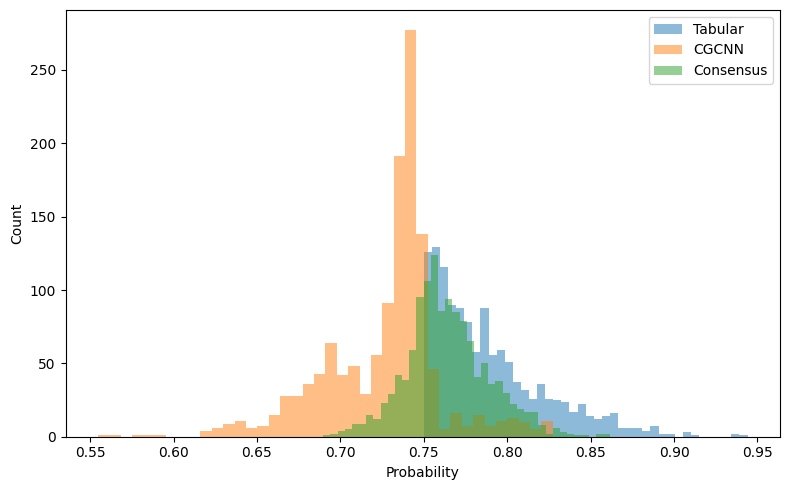

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("Files/output/final_consensus_clean_master.csv")

plt.figure(figsize=(8,5))

plt.hist(df["P_joint"], bins=40, alpha=0.5, label="Tabular")
plt.hist(df["P_cgcnn_max"], bins=40, alpha=0.5, label="CGCNN")
plt.hist(df["P_joint_final"], bins=40, alpha=0.5, label="Consensus")

plt.xlabel("Probability")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()

plt.savefig("Files/output/inverse_score_distribution.pdf", dpi=1200)
plt.show()


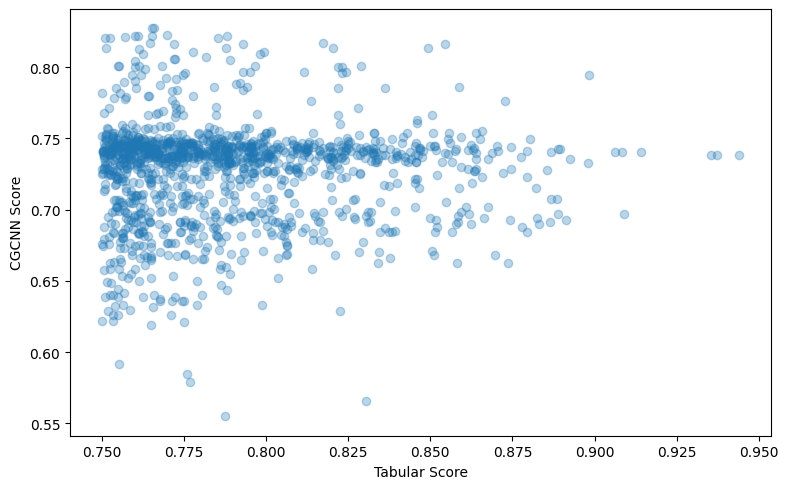

In [2]:
plt.figure(figsize=(8,5))

plt.scatter(df["P_joint"], df["P_cgcnn_max"], alpha=0.3)
plt.xlabel("Tabular Score")
plt.ylabel("CGCNN Score")
plt.tight_layout()

plt.savefig("Files/output/tabular_vs_cgcnn_scatter.pdf", dpi=1200)
plt.show()
